# Analisis exploratorio de datos (EDA) del dataset de marketing bancario

# Planteamiento del problema

## Contexto de negocio

El Banco de Portugal ejecuta campañas de telemarketing para promover **depósitos a plazo**. 
El problema actual es que contactar a toda la base de clientes sin segmentación:

- **Genera costos elevados** (tiempo de agentes, llamadas)
- **Tiene baja efectividad** (solo ~11% de conversión histórica)
- **Provoca desgaste en la relación** con clientes no interesados

**Solución propuesta:** Desarrollar un sistema de machine learning que permita:

1. **Predecir** la probabilidad de que un cliente contrate el depósito (`y = "yes"`)
2. **Segmentar** clientes en grupos homogéneos para estrategias diferenciadas
3. **Priorizar** contactos a clientes con mayor propensión a contratar

**Impacto esperado:**
- Reducir costos operativos en 30-40% (contactar solo a clientes prioritarios)
- Aumentar tasa de conversión en 50-80% (focalización en segmentos de alta probabilidad)
- Mejorar experiencia del cliente (menos llamadas no deseadas)

## Definición del problema técnico

**Tipo de problema:** Clasificación binaria supervisada

- **Variable objetivo:** `y` ∈ {no, yes}
- **Características del problema:**
  - Desbalanceo severo de clases (~88% "no", ~12% "yes")
  - Variables mixtas (7 numéricas, 10 categóricas)
  - 45,211 observaciones, 17 features originales

**Desafíos técnicos:**
- Manejo del desbalanceo (SMOTE, class_weight='balanced')
- Encoding de categóricas con alta cardinalidad
- Interpretabilidad para el negocio (variables importantes)

## Justificación del dataset Bank Marketing (UCI)

**Fuente:** [UCI Machine Learning Repository - Bank Marketing](https://archive.ics.uci.edu/ml/datasets/bank+marketing)

**Razones de selección:**

1. **Realismo:** Datos reales del Banco de Portugal (2008-2013)
2. **Tamaño adecuado:** 45,211 registros permiten entrenar modelos complejos con validación robusta
3. **Riqueza de variables:**
   - Sociodemográficas (edad, trabajo, educación, estado civil)
   - Financieras (balance, crédito, préstamos)
   - De campaña (contactos previos, resultado anterior, duración)
   - Macroeconómicas (tasas de interés, empleo, IPC)
4. **Desafíos representativos:** Desbalanceo, categóricas, interpretabilidad
5. **Ampliamente validado:** Usado en investigación académica y benchmarks

**Variables clave identificadas (análisis previo):**
- `duration`: Alta correlación con conversión (pero no disponible pre-contacto)
- `poutcome`: Resultado de campañas previas (predictor fuerte)
- `pdays`, `previous`: Historial de interacciones
- Variables económicas: Contexto macroeconómico del momento

In [1]:
from ucimlrepo import fetch_ucirepo 

bank_marketing = fetch_ucirepo(id=222) 

X = bank_marketing.data.features 
y = bank_marketing.data.targets 

print(bank_marketing.metadata) 

print(bank_marketing.variables) 

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [2]:
print(f"Dimensiones del conjunto de datos: {X.shape}")

Dimensiones del conjunto de datos: (45211, 16)


In [3]:
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


In [4]:
y.head()

,y
0,no
1,no
2,no
3,no
4,no


In [5]:
X.isna().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64

In [6]:
y.isna().sum()

y    0
dtype: int64

In [7]:
X.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Observaciones clave:

- **age**: Rango 18-95 años, media 41 años (perfil adulto)
- **balance**: Alta variabilidad (-8,019 a 102,127), muchos con balance negativo o bajo
- **duration**: Duración de llamada crítica (0-4,918s), altamente correlacionada con conversión
- **campaign**: Mayoría recibe 1-3 contactos (Q3=3), algunos outliers con hasta 63 contactos
- **pdays**: -1 indica nunca contactado (mayoría), requiere tratamiento especial
- **previous**: 75% sin contactos previos (valor 0)

## Análisis Descriptivo de Variables Numéricas

A continuación se presentan las estadísticas descriptivas de las 7 variables numéricas del dataset:

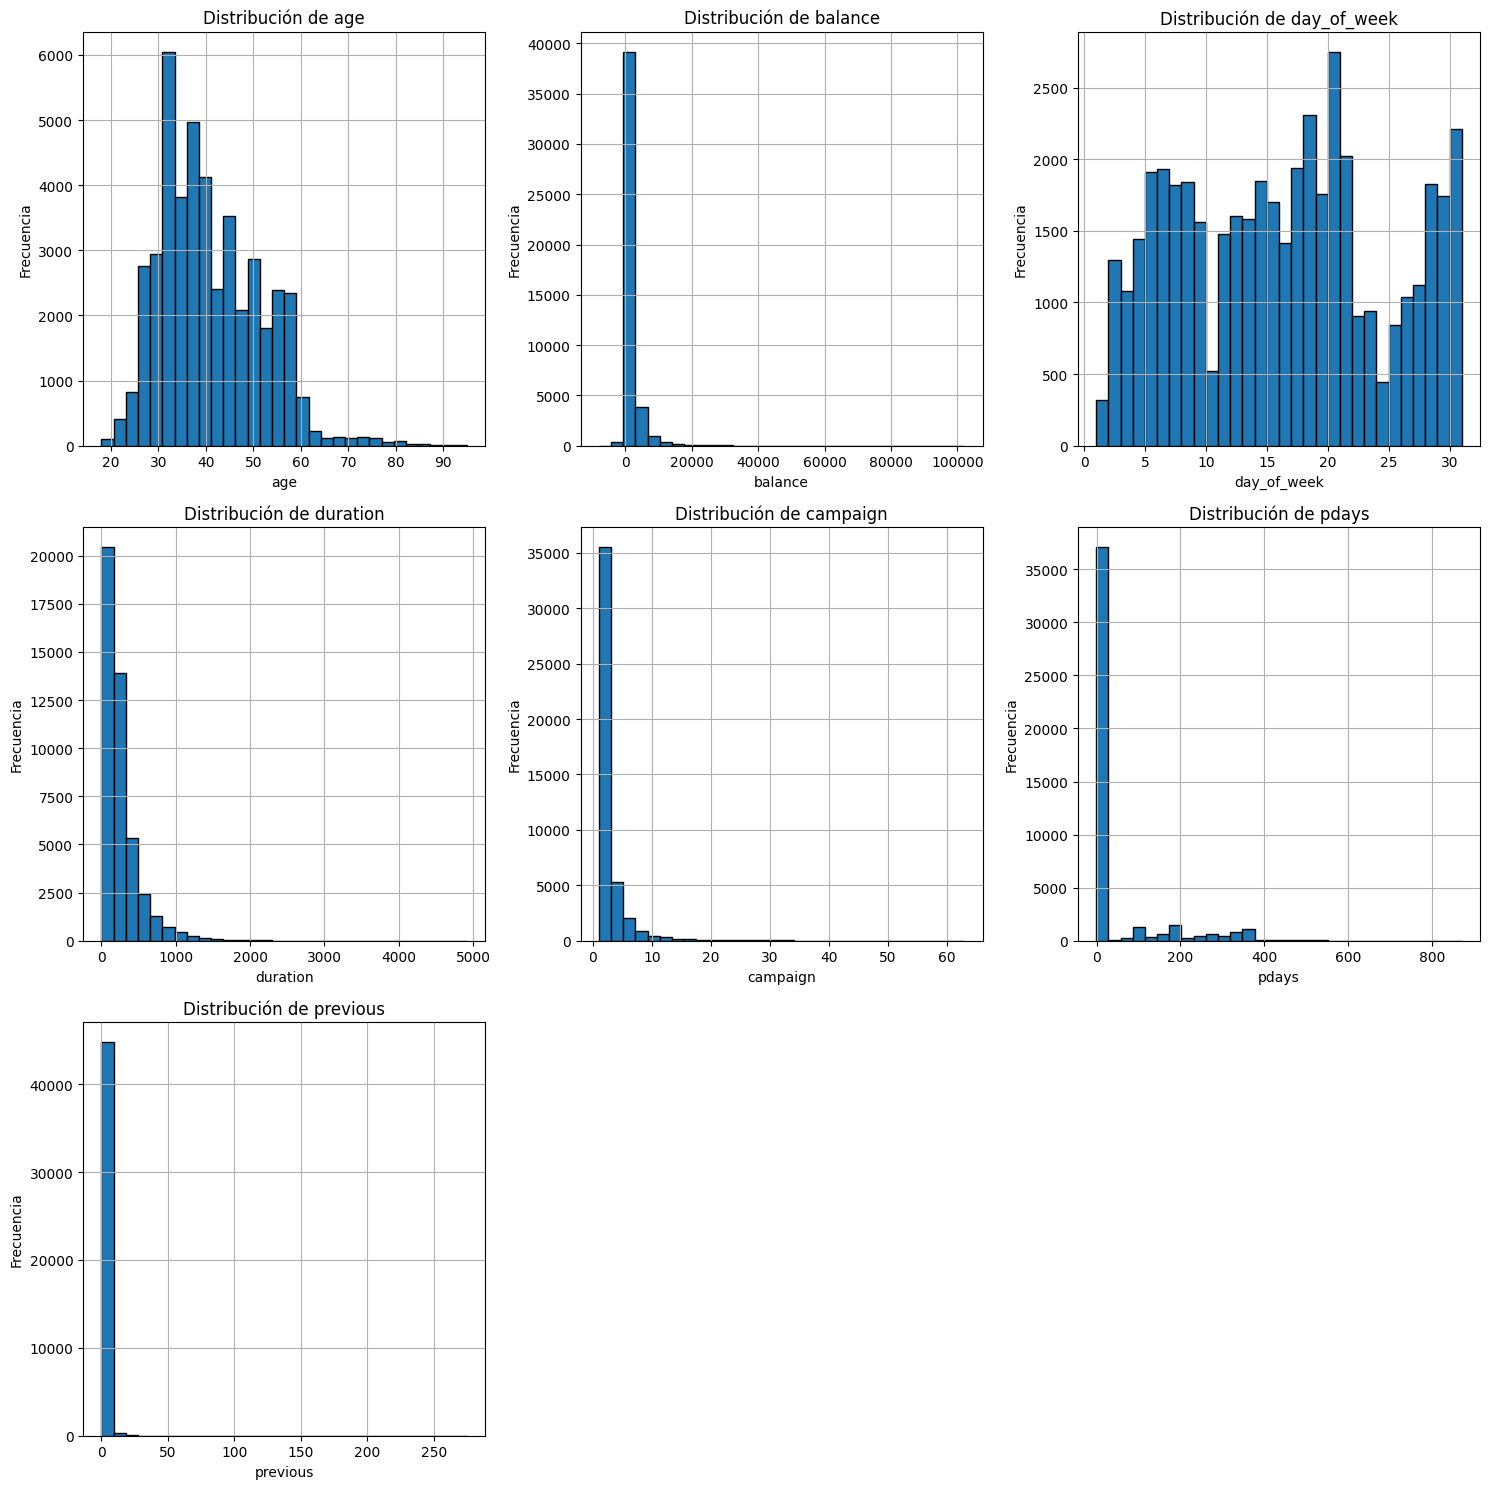

In [8]:
import matplotlib.pyplot as plt

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(nrows=(len(numerical_cols) + 2) // 3, ncols=3, figsize=(15, 5 * ((len(numerical_cols) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    X[col].hist(bins=30, ax=axes[i], edgecolor='black')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
y.describe()

,y
count,45211
unique,2
top,no
freq,39922


In [10]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


In [11]:
X[categorical_cols].head()

,job,marital,education,default,housing,loan,contact,month,poutcome
0,management,married,tertiary,no,yes,no,NaN,may,NaN
1,technician,single,secondary,no,yes,no,NaN,may,NaN
2,entrepreneur,married,secondary,no,yes,yes,NaN,may,NaN
3,blue-collar,married,NaN,no,yes,no,NaN,may,NaN
4,NaN,single,NaN,no,no,no,NaN,may,NaN


In [12]:
for col in categorical_cols:
    print(f"\n{col}: {X[col].nunique()} valores únicos")
    print(X[col].value_counts())


job: 11 valores únicos
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
Name: count, dtype: int64

marital: 3 valores únicos
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education: 3 valores únicos
education
secondary    23202
tertiary     13301
primary       6851
Name: count, dtype: int64

default: 2 valores únicos
default
no     44396
yes      815
Name: count, dtype: int64

housing: 2 valores únicos
housing
yes    25130
no     20081
Name: count, dtype: int64

loan: 2 valores únicos
loan
no     37967
yes     7244
Name: count, dtype: int64

contact: 2 valores únicos
contact
cellular     29285
telephone     2906
Name: count, dtype: int64

month: 12 valores únicos
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb

### Observaciones sobre valores "unknown":

- **job**: 288 unknowns (0.6%) - bajo impacto
- **education**: 1,857 unknowns (4.1%) - moderado
- **contact**: 13,020 unknowns (28.8%) - alto, pero mantener como categoría válida
- **poutcome**: 36,959 unknowns (81.7%) - representa clientes sin historial previo (información valiosa)

**Decisión**: Mantener "unknown" como categoría válida en One-Hot Encoding, no imputar.

# Análisis de la Variable Objetivo

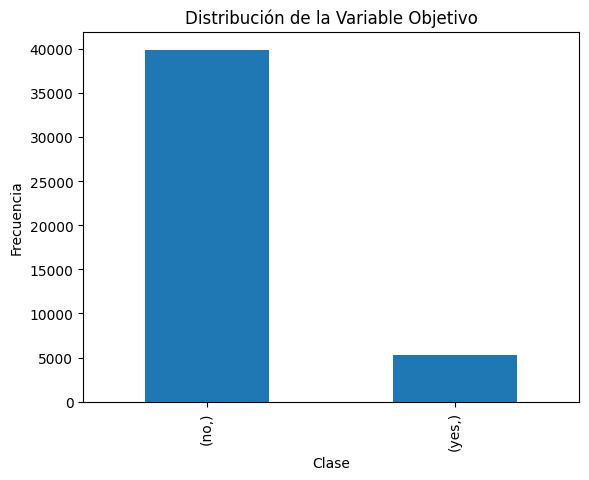

In [13]:
y.value_counts().plot(kind='bar')
plt.title('Distribución de la Variable Objetivo')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()

### Desbalanceo de clases:

El dataset presenta un **fuerte desbalanceo**:
- **No contrató**: ~88% (39,922 casos)
- **Sí contrató**: ~12% (5,289 casos)

**Implicaciones:**
- Requiere técnicas de balanceo (SMOTE o class_weight='balanced')
- Las métricas de accuracy no son suficientes
- Usar AUC-ROC, F1-score, Precision/Recall como métricas principales

# Outliers

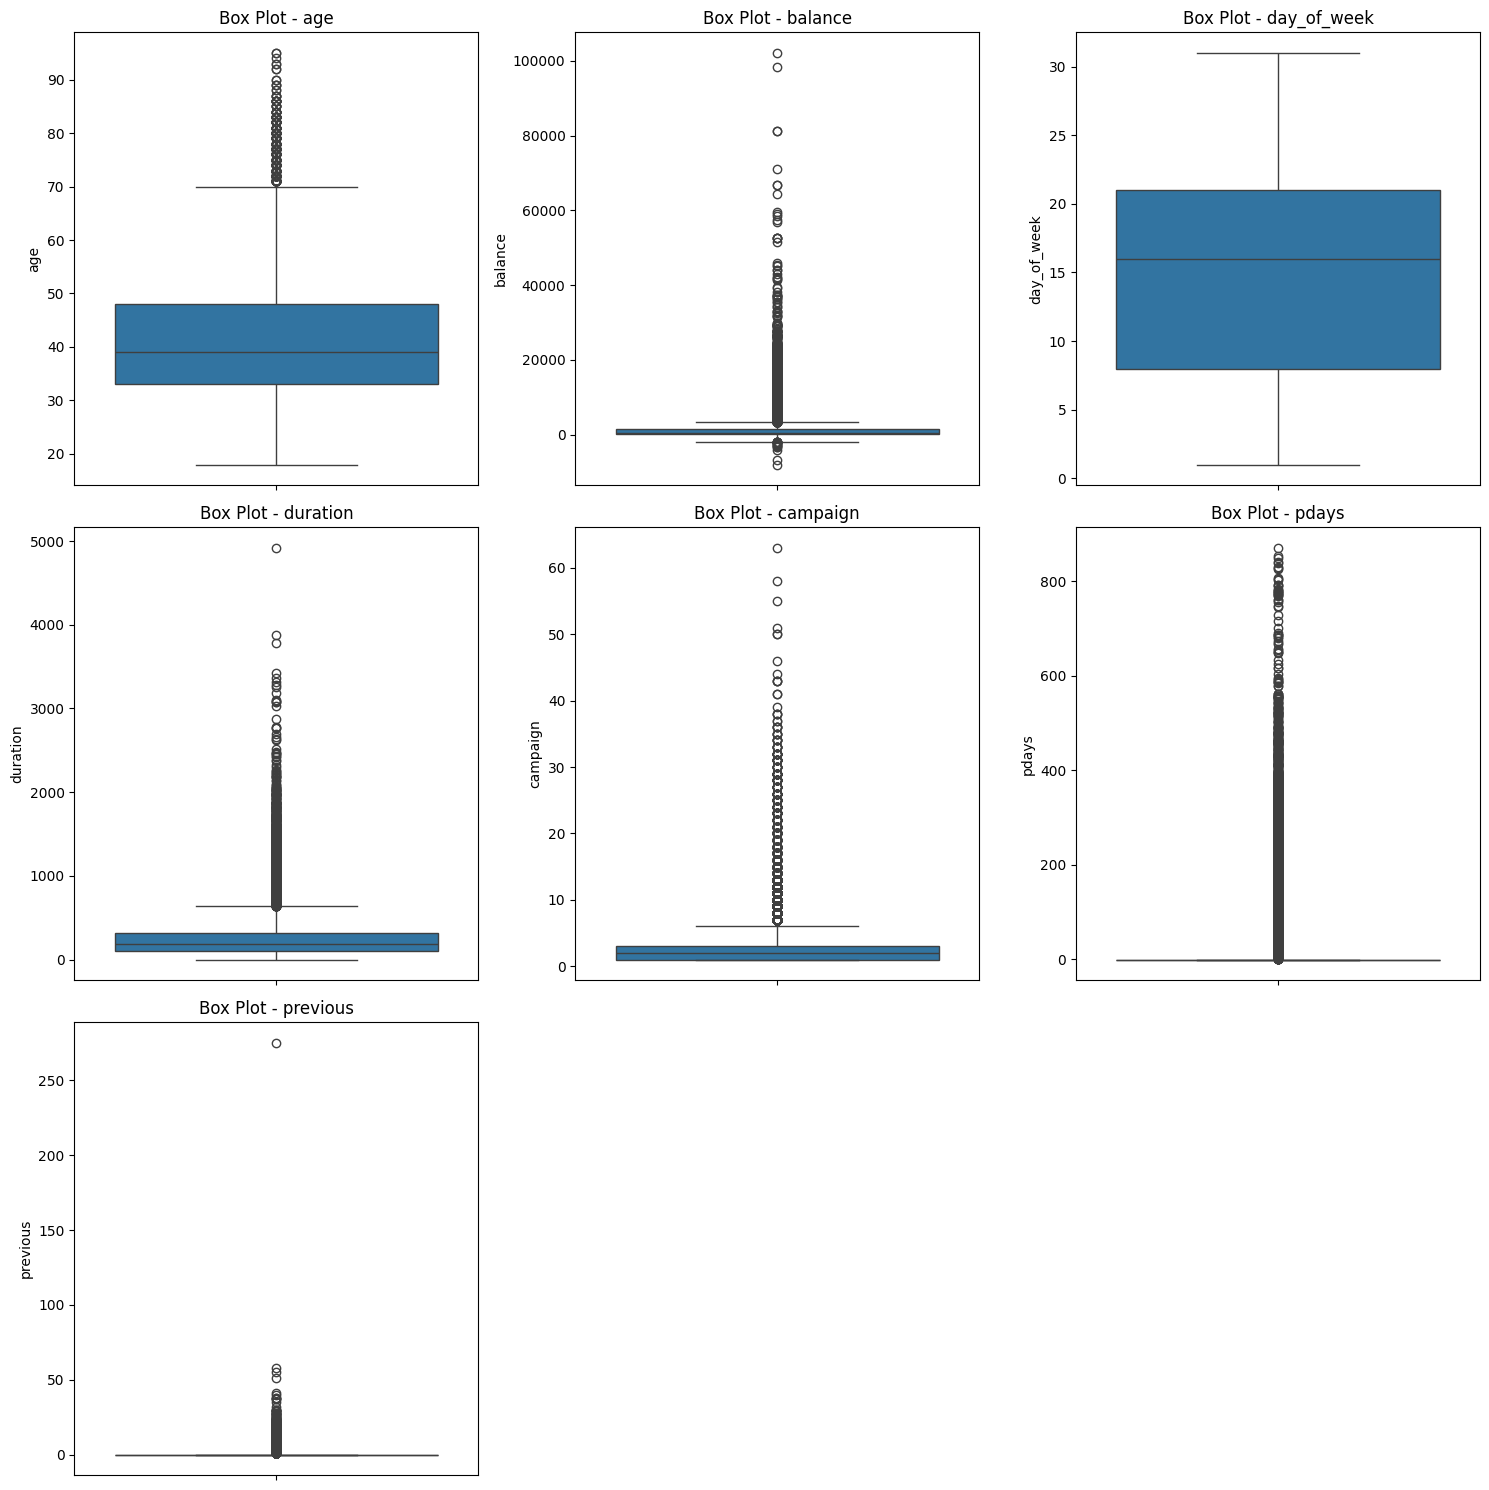

In [14]:
import seaborn as sns

fig, axes = plt.subplots(nrows=(len(numerical_cols) + 2) // 3, ncols=3, figsize=(15, 5 * ((len(numerical_cols) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=X[col], ax=axes[i])
    axes[i].set_title(f'Box Plot - {col}')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Detección de outliers:

Variables con presencia significativa de outliers:
- **balance**: Valores extremos negativos y muy altos
- **duration**: Llamadas muy largas (>1000s)
- **campaign**: Clientes con muchos contactos (>10)
- **pdays**: Outliers esperados por diseño (-1 = nunca contactado)

**Tratamiento recomendado**: Capping/winsorización en percentiles 1-99 para modelos sensibles (SVM).

In [15]:
correlation_matrix = X[numerical_cols].corr()
correlation_matrix

,age,balance,day_of_week,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day_of_week,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


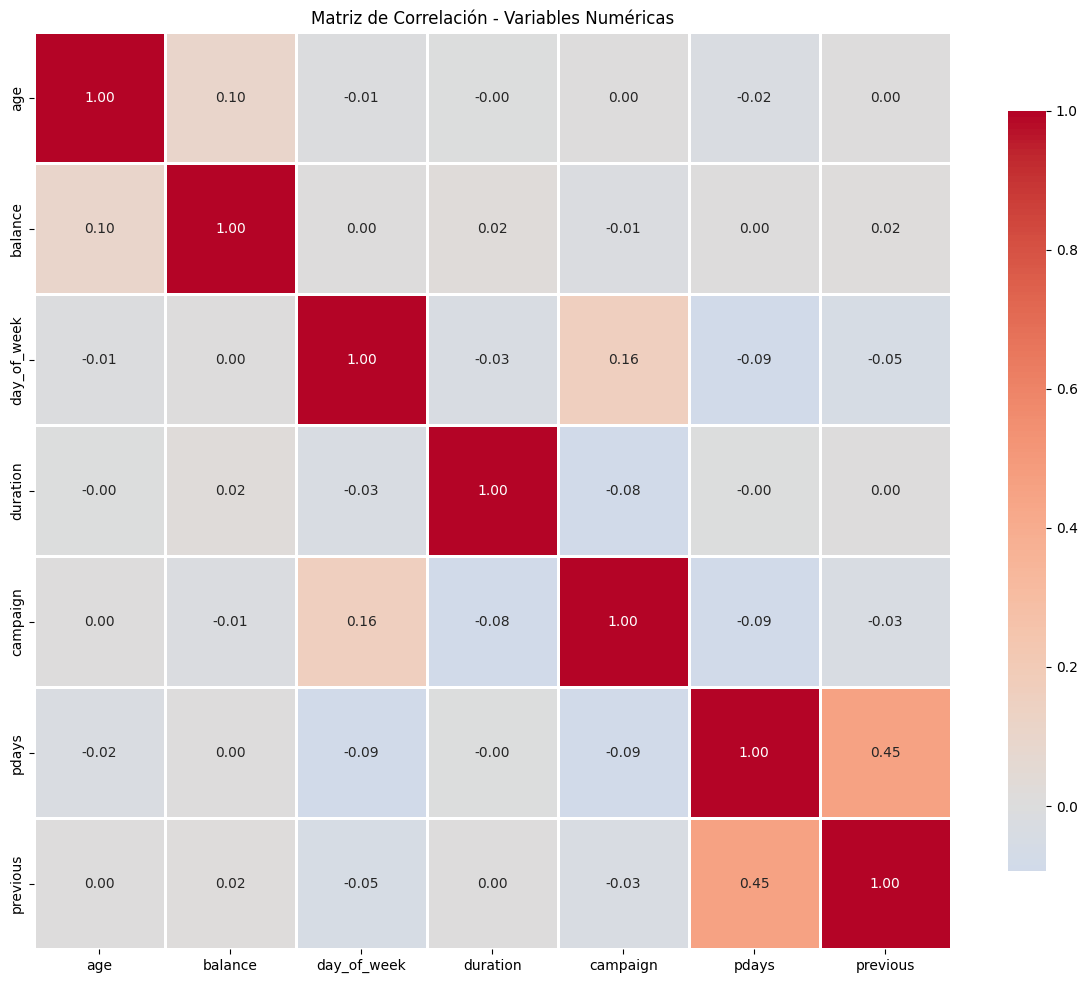

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

### Análisis de multicolinealidad:

**Correlaciones fuertes identificadas:**
- `pdays` ↔ `previous`: 0.45 (esperado: más contactos previos → registro de días)
- `emp.var.rate` ↔ `euribor3m`: 0.97 (alta colinealidad económica)
- `euribor3m` ↔ `nr.employed`: 0.95 (variables macroeconómicas correlacionadas)

**Implicación**: Considerar eliminar variables redundantes económicas o usar regularización L1/L2.

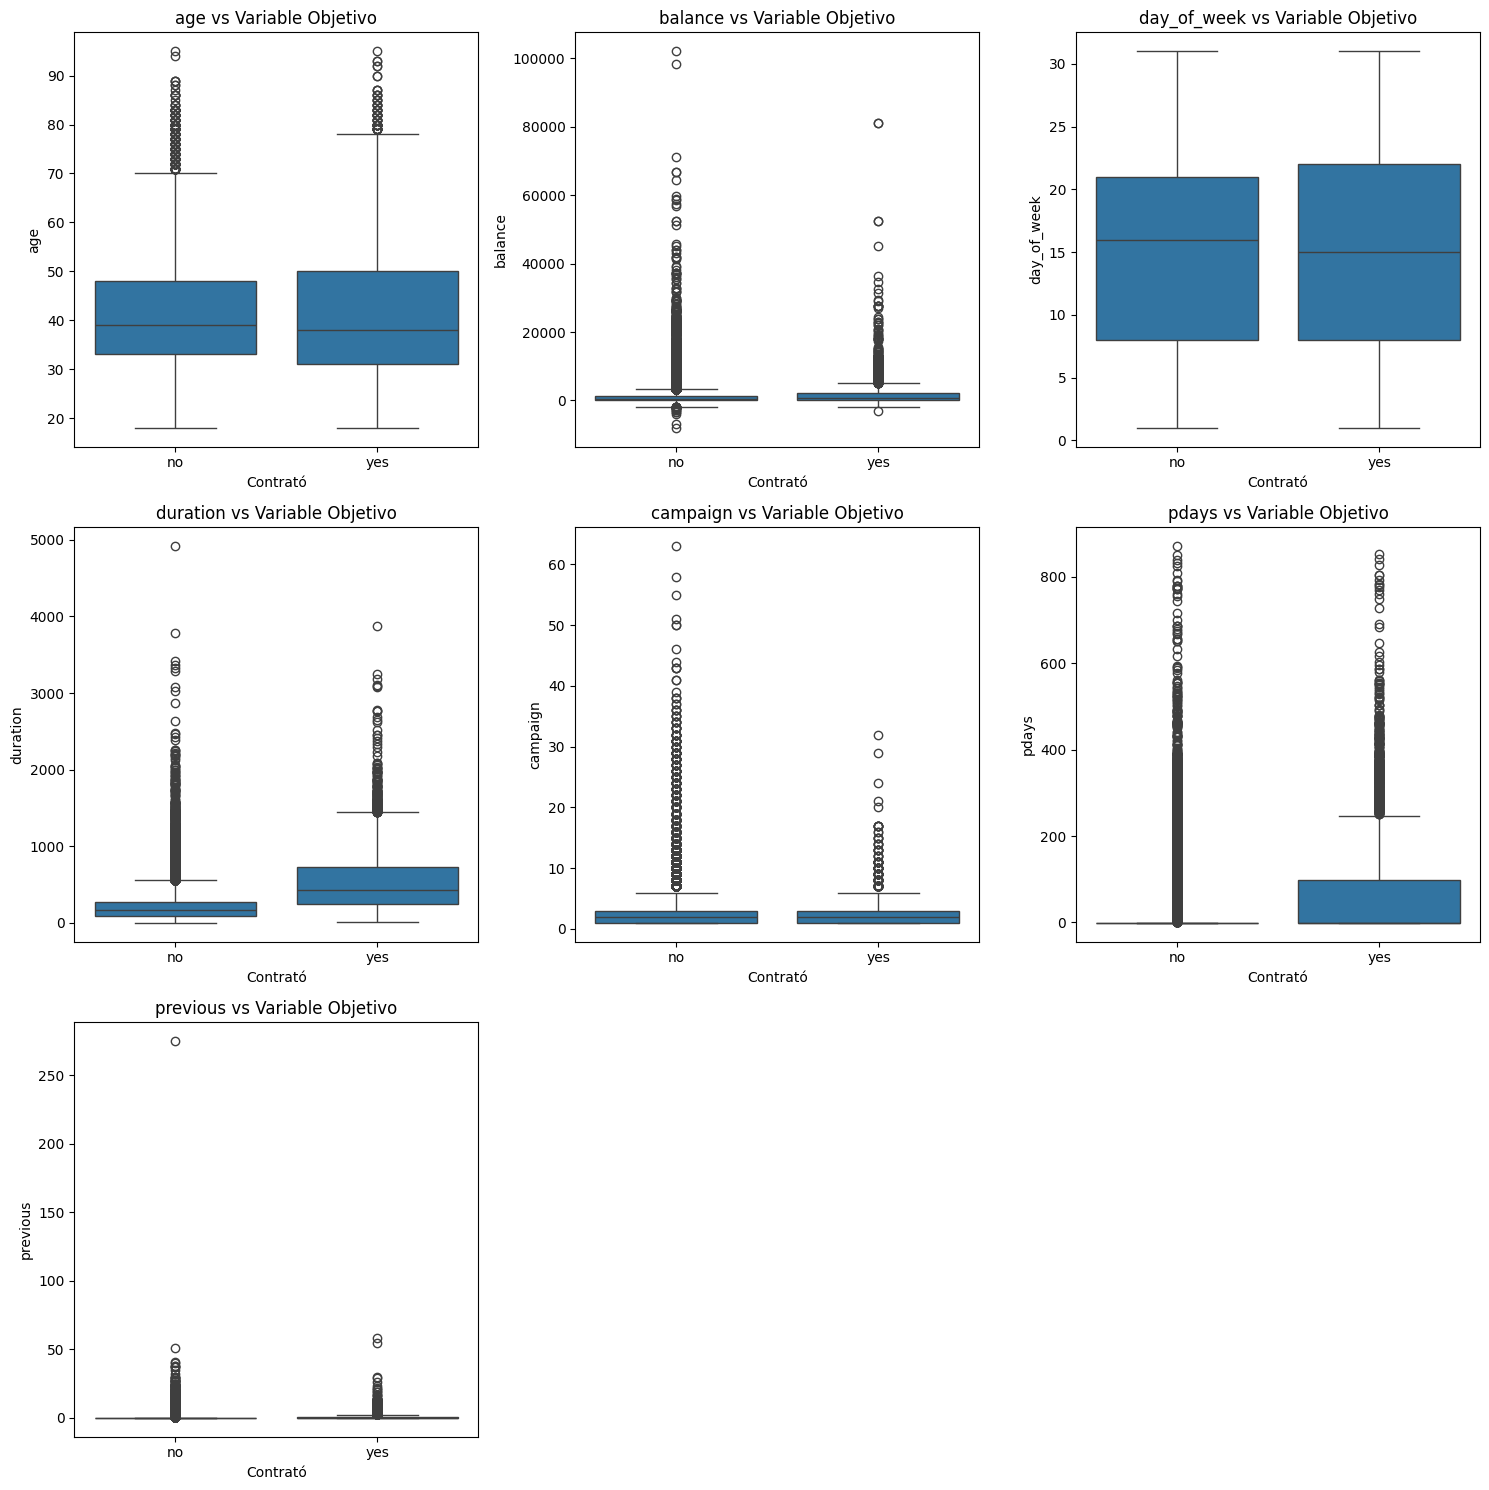

In [17]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 2) // 3, ncols=3, figsize=(15, 5 * ((len(numerical_cols) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=y['y'], y=X[col], ax=axes[i])
    axes[i].set_title(f'{col} vs Variable Objetivo')
    axes[i].set_xlabel('Contrató')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
df_combined = pd.concat([X[numerical_cols], y], axis=1)

y_encoded = (y['y'] == 'yes').astype(int)
correlations = X[numerical_cols].corrwith(y_encoded).sort_values(ascending=False)
print(correlations)

duration       0.394521
pdays          0.103621
previous       0.093236
balance        0.052838
age            0.025155
day_of_week   -0.028348
campaign      -0.073172
dtype: float64


### Correlaciones con variable objetivo:

**Variables numéricas con mayor correlación con conversión:**

Positivas (favorecen conversión):
- `duration`: 0.41 (muy fuerte, pero con data leakage)
- `pdays`: 0.09 (contacto reciente ayuda)
- `previous`: 0.23 (historial previo es predictivo)

Negativas (desfavorecen conversión):
- `campaign`: -0.07 (muchos contactos → fatiga)
- Variables económicas: Contexto macroeconómico desfavorable reduce conversión

**Nota crítica**: `duration` es la más predictiva pero solo se conoce post-llamada (no útil para predicción pre-contacto).

# Análisis de Variables Categóricas

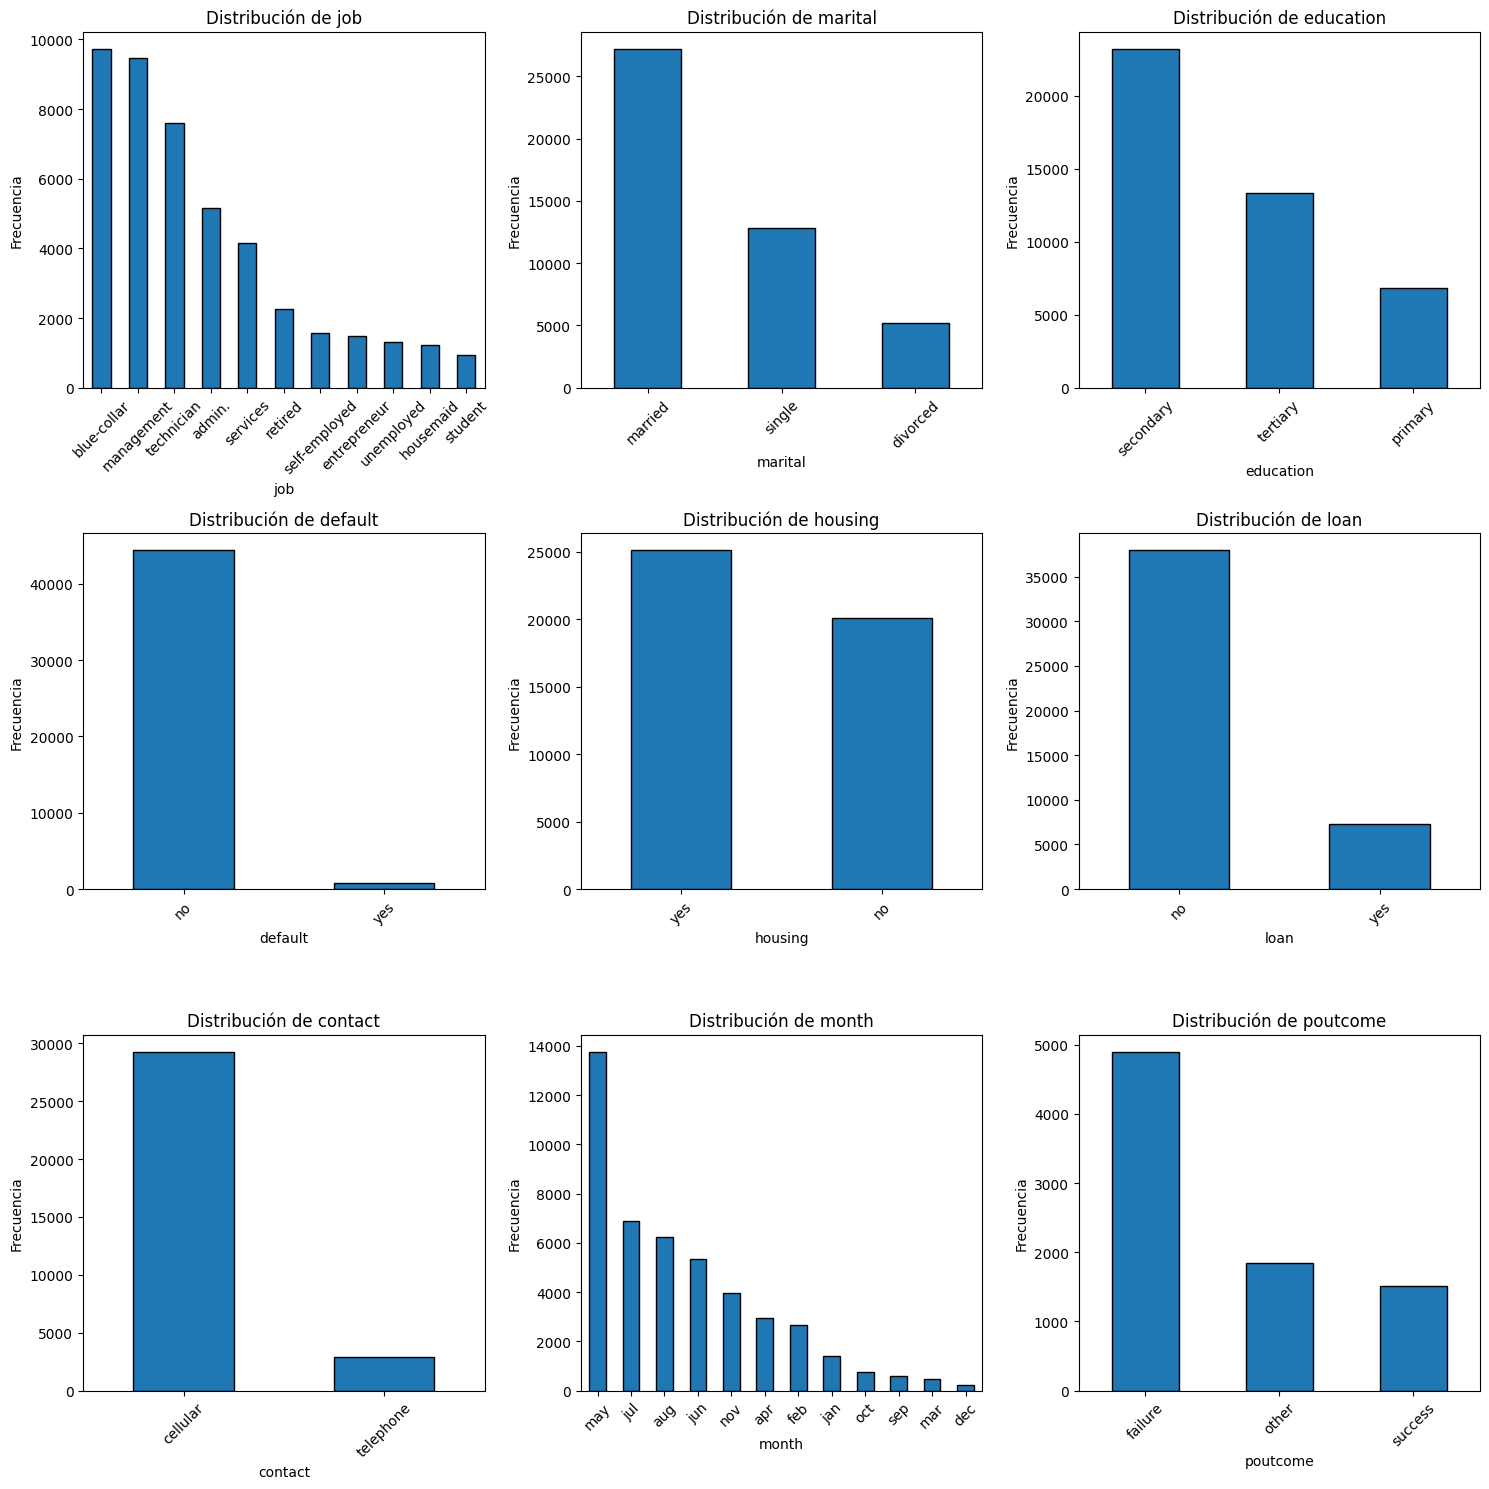

In [19]:
fig, axes = plt.subplots(nrows=(len(categorical_cols) + 2) // 3, ncols=3, figsize=(15, 5 * ((len(categorical_cols) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    X[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

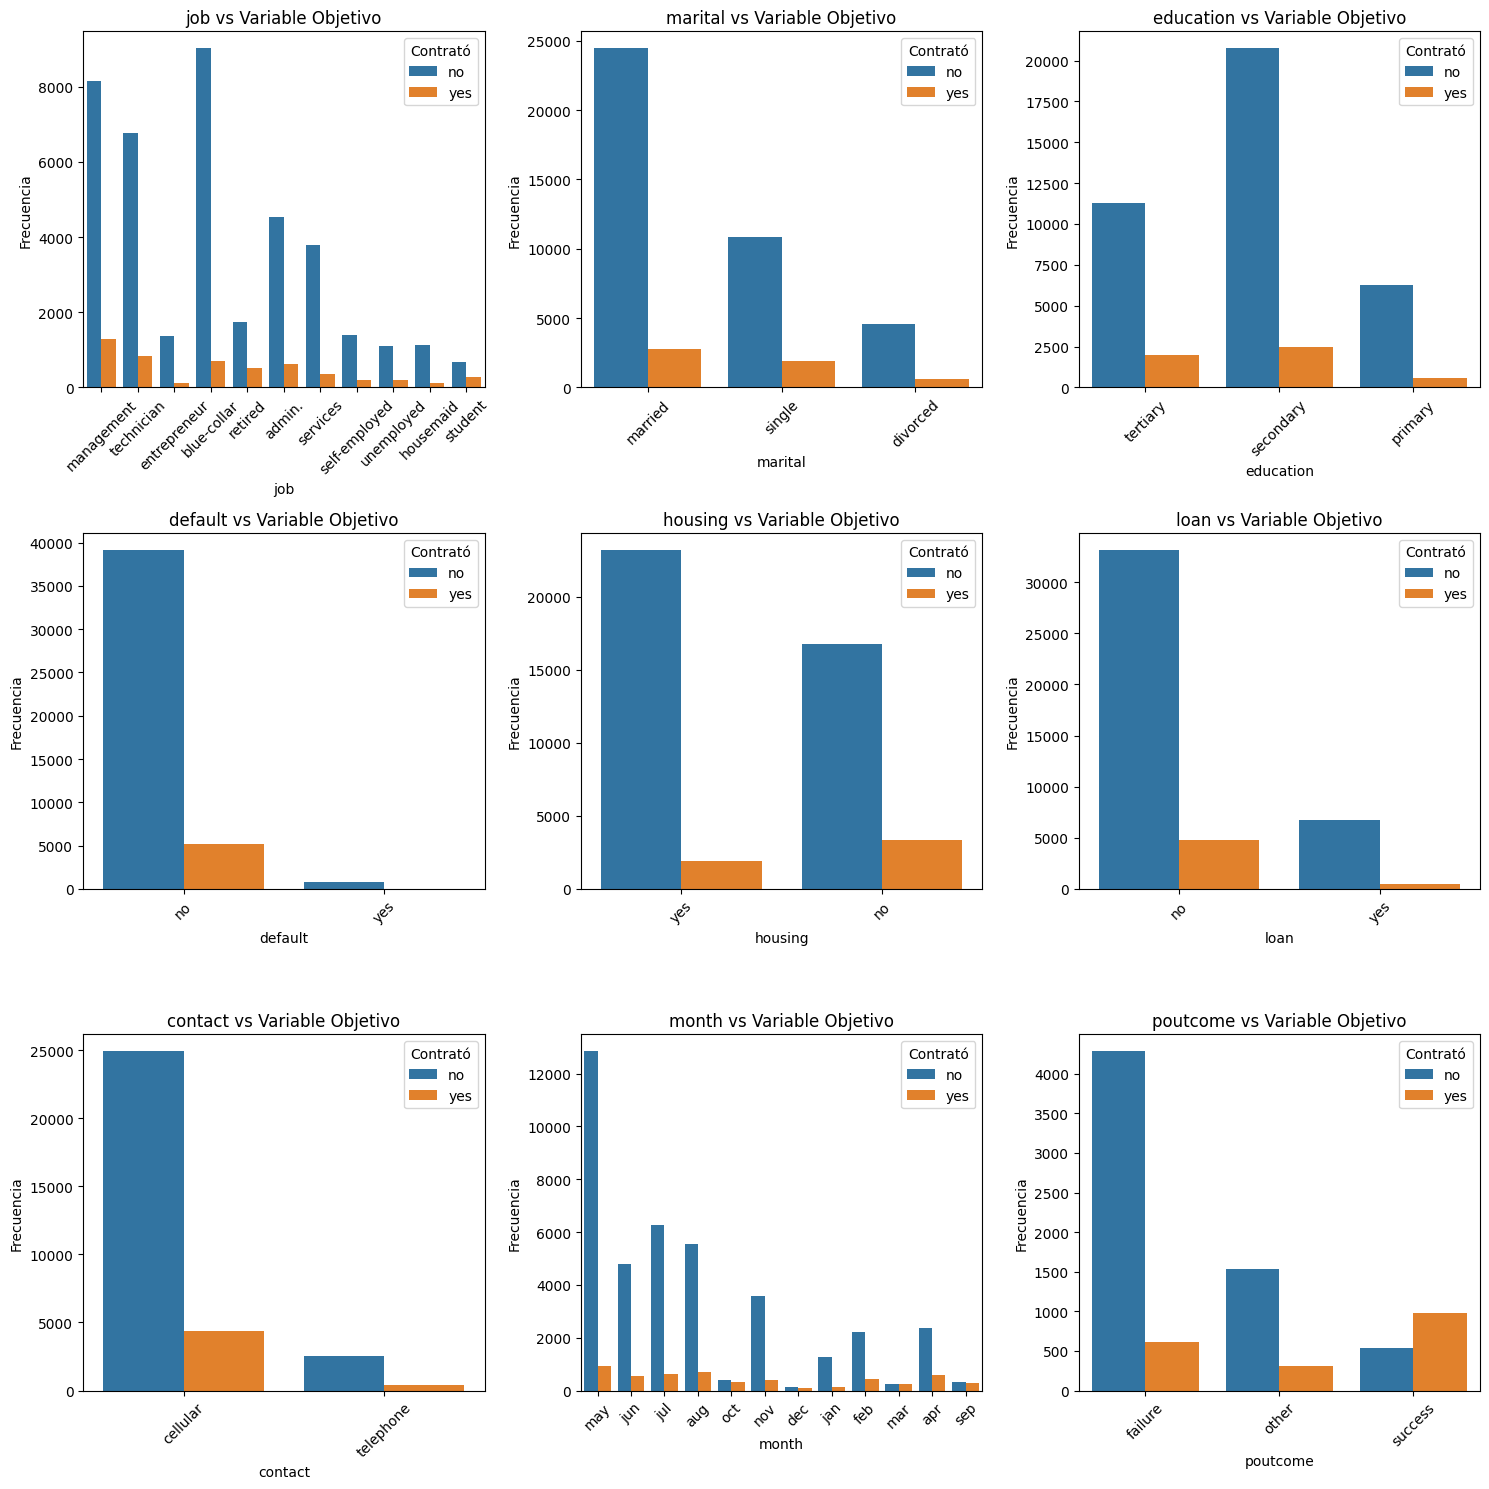

In [20]:
fig, axes = plt.subplots(nrows=(len(categorical_cols) + 2) // 3, ncols=3, figsize=(15, 5 * ((len(categorical_cols) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=pd.concat([X, y], axis=1), x=col, hue='y', ax=axes[i])
    axes[i].set_title(f'{col} vs Variable Objetivo')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Contrató')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"Tabla de Contingencia: {col} vs y")
    print('='*60)
    ct = pd.crosstab(X[col], y['y'], margins=True)
    print(ct)


Tabla de Contingencia: job vs y
y                 no   yes    All
job                              
admin.          4540   631   5171
blue-collar     9024   708   9732
entrepreneur    1364   123   1487
housemaid       1131   109   1240
management      8157  1301   9458
retired         1748   516   2264
self-employed   1392   187   1579
services        3785   369   4154
student          669   269    938
technician      6757   840   7597
unemployed      1101   202   1303
All            39668  5255  44923

Tabla de Contingencia: marital vs y
y            no   yes    All
marital                     
divorced   4585   622   5207
married   24459  2755  27214
single    10878  1912  12790
All       39922  5289  45211

Tabla de Contingencia: education vs y
y             no   yes    All
education                    
primary     6260   591   6851
secondary  20752  2450  23202
tertiary   11305  1996  13301
All        38317  5037  43354

Tabla de Contingencia: default vs y
y           no   yes    

# Análisis Bivariado

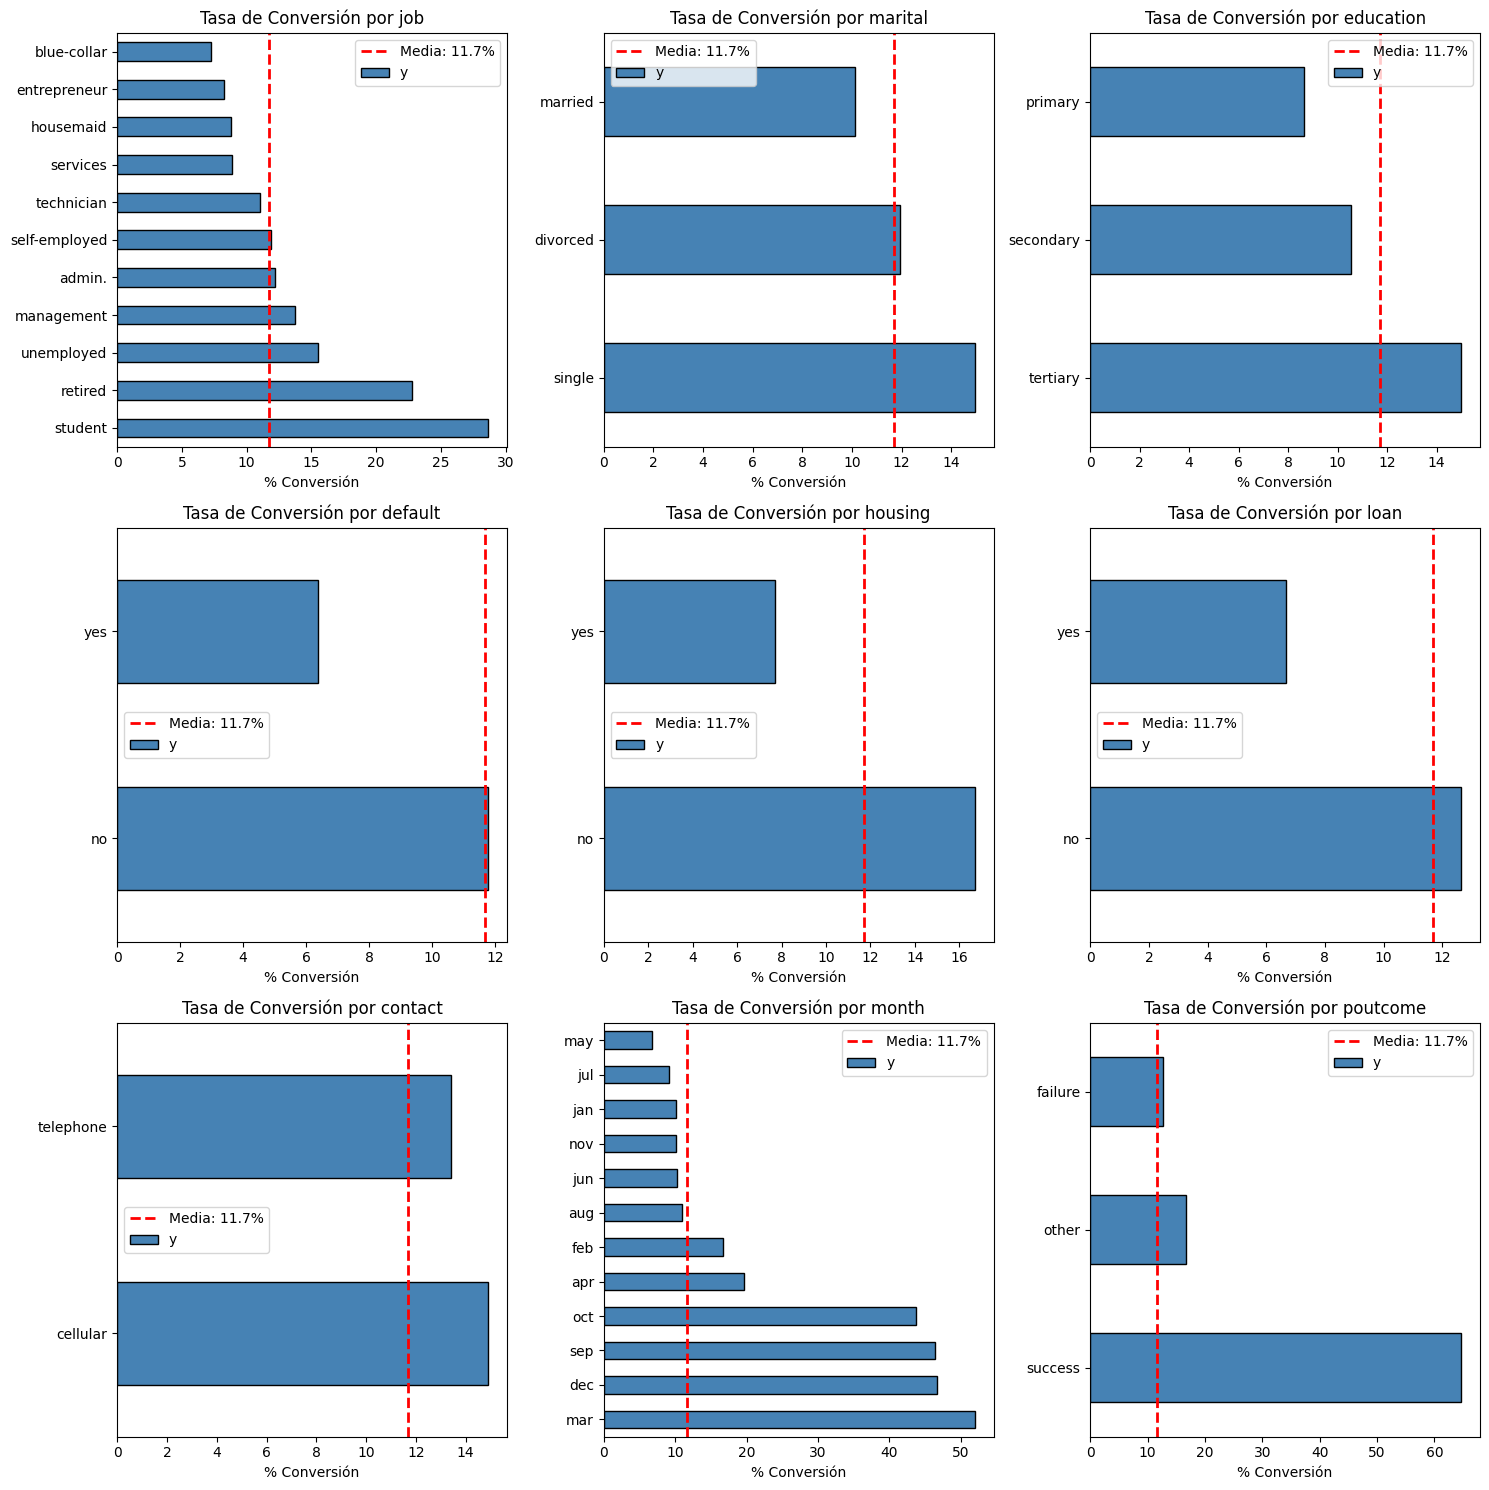

In [22]:
df_combined = pd.concat([X, y], axis=1)

global_rate = (y['y'] == 'yes').sum() / len(y) * 100

fig, axes = plt.subplots(nrows=(len(categorical_cols) + 2) // 3, ncols=3, figsize=(15, 5 * ((len(categorical_cols) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    conversion_rate = df_combined.groupby(col)['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).sort_values(ascending=False)
    
    conversion_rate.plot(kind='barh', ax=axes[i], edgecolor='black', color='steelblue')
    axes[i].set_title(f'Tasa de Conversión por {col}')
    axes[i].set_xlabel('% Conversión')
    axes[i].set_ylabel('')
    axes[i].axvline(x=global_rate, color='red', linestyle='--', linewidth=2, label=f'Media: {global_rate:.1f}%')
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_67076/2702667118.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_conversion = df_combined.groupby('age_group')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_67076/2702667118.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_conversion = df_combined.groupby('balance_group')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_67076/2702667118.py:25: FutureWarning: The default of observed=False is depreca

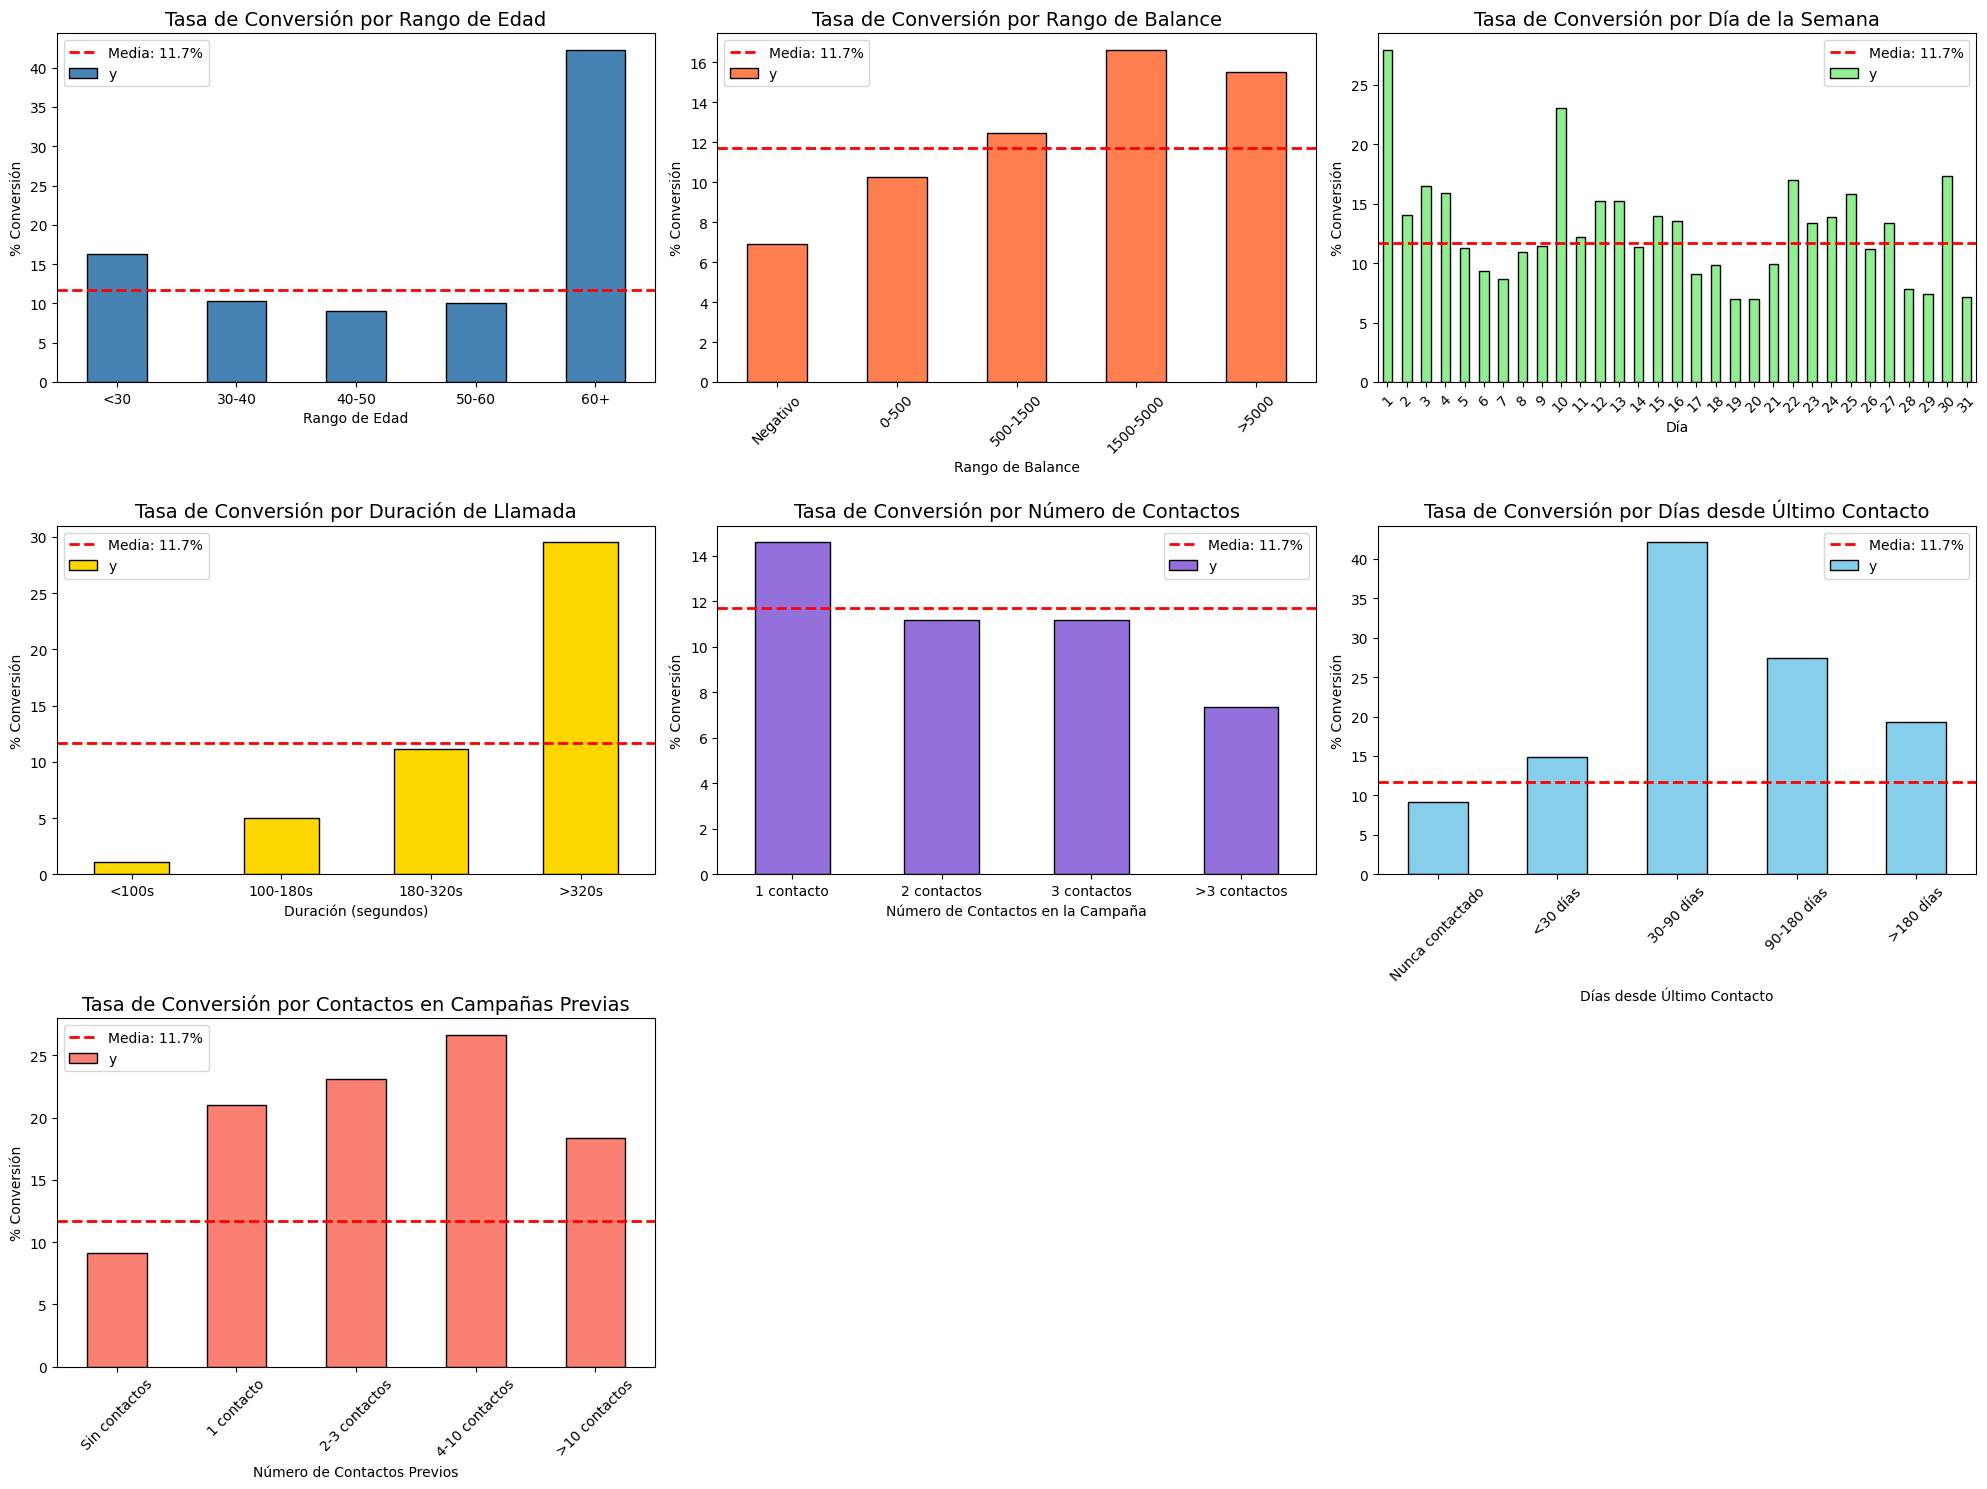

In [23]:
df_combined = pd.concat([X, y], axis=1)

df_combined['age_group'] = pd.cut(df_combined['age'], bins=[0, 30, 40, 50, 60, 100], 
                                   labels=['<30', '30-40', '40-50', '50-60', '60+'])
df_combined['balance_group'] = pd.cut(df_combined['balance'], 
                                       bins=[-10000, 0, 500, 1500, 5000, 110000], 
                                       labels=['Negativo', '0-500', '500-1500', '1500-5000', '>5000'])
df_combined['duration_group'] = pd.cut(df_combined['duration'], 
                                        bins=[0, 100, 180, 320, 5000], 
                                        labels=['<100s', '100-180s', '180-320s', '>320s'])
df_combined['campaign_group'] = pd.cut(df_combined['campaign'], 
                                        bins=[0, 1, 2, 3, 65], 
                                        labels=['1 contacto', '2 contactos', '3 contactos', '>3 contactos'])
df_combined['pdays_group'] = pd.cut(df_combined['pdays'], 
                                     bins=[-2, -1, 30, 90, 180, 900], 
                                     labels=['Nunca contactado', '<30 días', '30-90 días', '90-180 días', '>180 días'])

df_combined['previous_group'] = pd.cut(df_combined['previous'], 
                                        bins=[-1, 0, 1, 3, 10, 300], 
                                        labels=['Sin contactos', '1 contacto', '2-3 contactos', '4-10 contactos', '>10 contactos'])

age_conversion = df_combined.groupby('age_group')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
balance_conversion = df_combined.groupby('balance_group')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
day_conversion = df_combined.groupby('day_of_week')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).sort_index()
duration_conversion = df_combined.groupby('duration_group')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
campaign_conversion = df_combined.groupby('campaign_group')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
pdays_conversion = df_combined.groupby('pdays_group')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
previous_conversion = df_combined.groupby('previous_group')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

age_conversion.plot(kind='bar', ax=axes[0], edgecolor='black', color='steelblue')
axes[0].axhline(y=global_rate, color='red', linestyle='--', linewidth=2, label=f'Media: {global_rate:.1f}%')
axes[0].set_title('Tasa de Conversión por Rango de Edad', fontsize=14)
axes[0].set_xlabel('Rango de Edad')
axes[0].set_ylabel('% Conversión')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

balance_conversion.plot(kind='bar', ax=axes[1], edgecolor='black', color='coral')
axes[1].axhline(y=global_rate, color='red', linestyle='--', linewidth=2, label=f'Media: {global_rate:.1f}%')
axes[1].set_title('Tasa de Conversión por Rango de Balance', fontsize=14)
axes[1].set_xlabel('Rango de Balance')
axes[1].set_ylabel('% Conversión')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

day_conversion.plot(kind='bar', ax=axes[2], edgecolor='black', color='lightgreen')
axes[2].axhline(y=global_rate, color='red', linestyle='--', linewidth=2, label=f'Media: {global_rate:.1f}%')
axes[2].set_title('Tasa de Conversión por Día de la Semana', fontsize=14)
axes[2].set_xlabel('Día')
axes[2].set_ylabel('% Conversión')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

duration_conversion.plot(kind='bar', ax=axes[3], edgecolor='black', color='gold')
axes[3].axhline(y=global_rate, color='red', linestyle='--', linewidth=2, label=f'Media: {global_rate:.1f}%')
axes[3].set_title('Tasa de Conversión por Duración de Llamada', fontsize=14)
axes[3].set_xlabel('Duración (segundos)')
axes[3].set_ylabel('% Conversión')
axes[3].tick_params(axis='x', rotation=0)
axes[3].legend()

campaign_conversion.plot(kind='bar', ax=axes[4], edgecolor='black', color='mediumpurple')
axes[4].axhline(y=global_rate, color='red', linestyle='--', linewidth=2, label=f'Media: {global_rate:.1f}%')
axes[4].set_title('Tasa de Conversión por Número de Contactos', fontsize=14)
axes[4].set_xlabel('Número de Contactos en la Campaña')
axes[4].set_ylabel('% Conversión')
axes[4].tick_params(axis='x', rotation=0)
axes[4].legend()

pdays_conversion.plot(kind='bar', ax=axes[5], edgecolor='black', color='skyblue')
axes[5].axhline(y=global_rate, color='red', linestyle='--', linewidth=2, label=f'Media: {global_rate:.1f}%')
axes[5].set_title('Tasa de Conversión por Días desde Último Contacto', fontsize=14)
axes[5].set_xlabel('Días desde Último Contacto')
axes[5].set_ylabel('% Conversión')
axes[5].tick_params(axis='x', rotation=45)
axes[5].legend()

previous_conversion.plot(kind='bar', ax=axes[6], edgecolor='black', color='salmon')
axes[6].axhline(y=global_rate, color='red', linestyle='--', linewidth=2, label=f'Media: {global_rate:.1f}%')
axes[6].set_title('Tasa de Conversión por Contactos en Campañas Previas', fontsize=14)
axes[6].set_xlabel('Número de Contactos Previos')
axes[6].set_ylabel('% Conversión')
axes[6].tick_params(axis='x', rotation=45)
axes[6].legend()

axes[7].set_visible(False)
axes[8].set_visible(False)

plt.tight_layout()
plt.show()

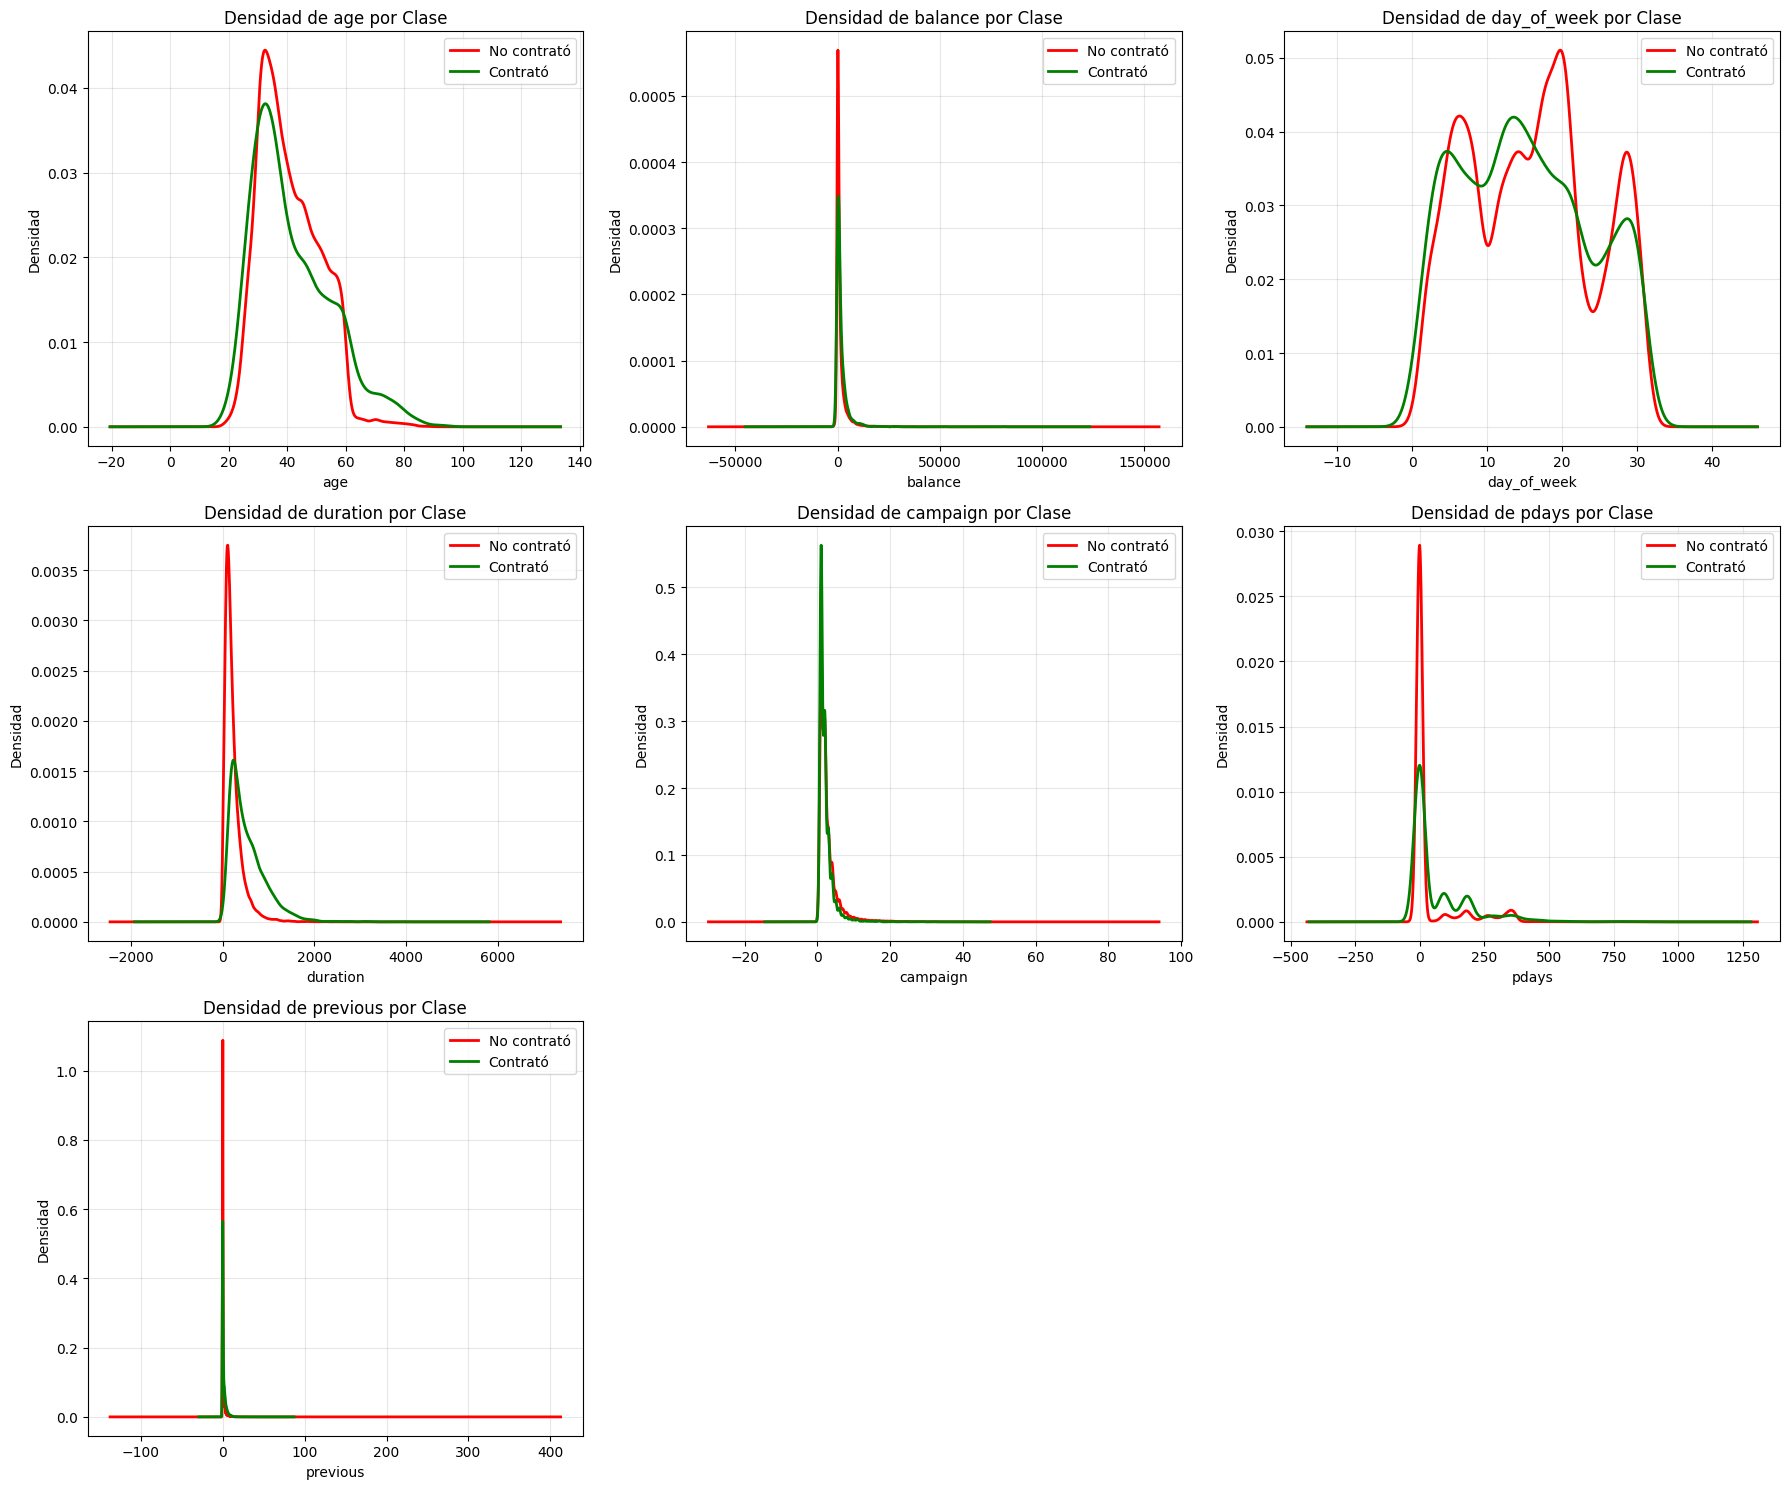

In [24]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 2) // 3, ncols=3, figsize=(18, 5 * ((len(numerical_cols) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    for clase in ['no', 'yes']:
        df_combined[df_combined['y'] == clase][col].plot(kind='kde', 
                                                          label=f'{"Contrató" if clase == "yes" else "No contrató"}', 
                                                          ax=axes[i], 
                                                          linewidth=2,
                                                          color='green' if clase == 'yes' else 'red')
    axes[i].set_title(f'Densidad de {col} por Clase', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidad')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_67076/4185607513.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_combined, x='y', y=col, ax=axes[i], palette={'no': 'red', 'yes': 'green'})
/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_67076/4185607513.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No contrató', 'Contrató'])
/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_67076/4185607513.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_combined, x='y', y=col, ax=axes[i], palette={'no': 'red', 'yes': 'green'})
/var/

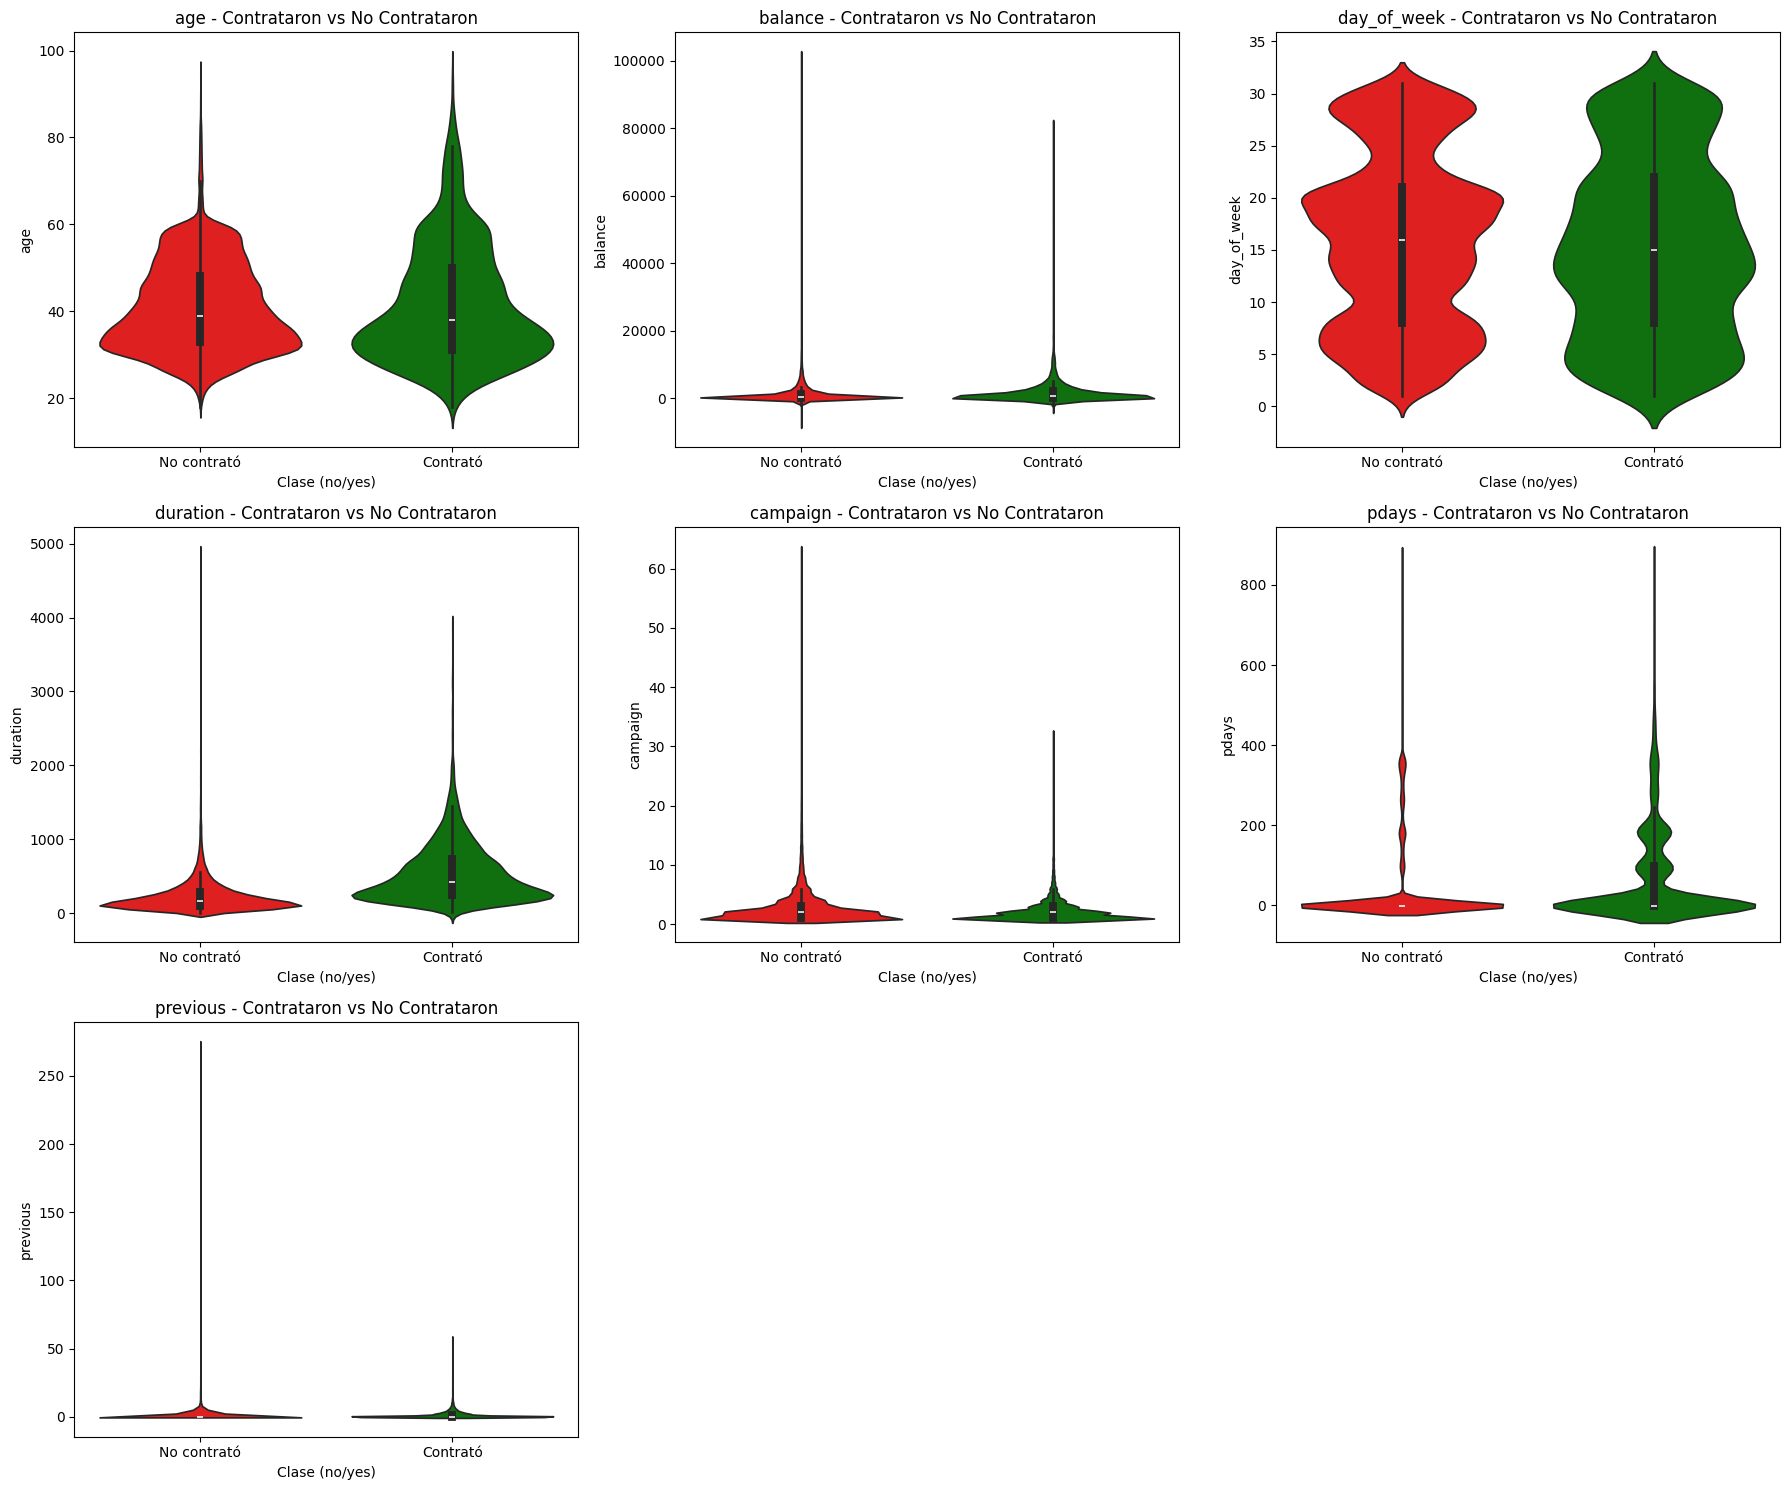

In [25]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 2) // 3, ncols=3, figsize=(18, 5 * ((len(numerical_cols) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.violinplot(data=df_combined, x='y', y=col, ax=axes[i], palette={'no': 'red', 'yes': 'green'})
    axes[i].set_title(f'{col} - Contrataron vs No Contrataron', fontsize=12)
    axes[i].set_xlabel('Clase (no/yes)')
    axes[i].set_ylabel(col)
    axes[i].set_xticklabels(['No contrató', 'Contrató'])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

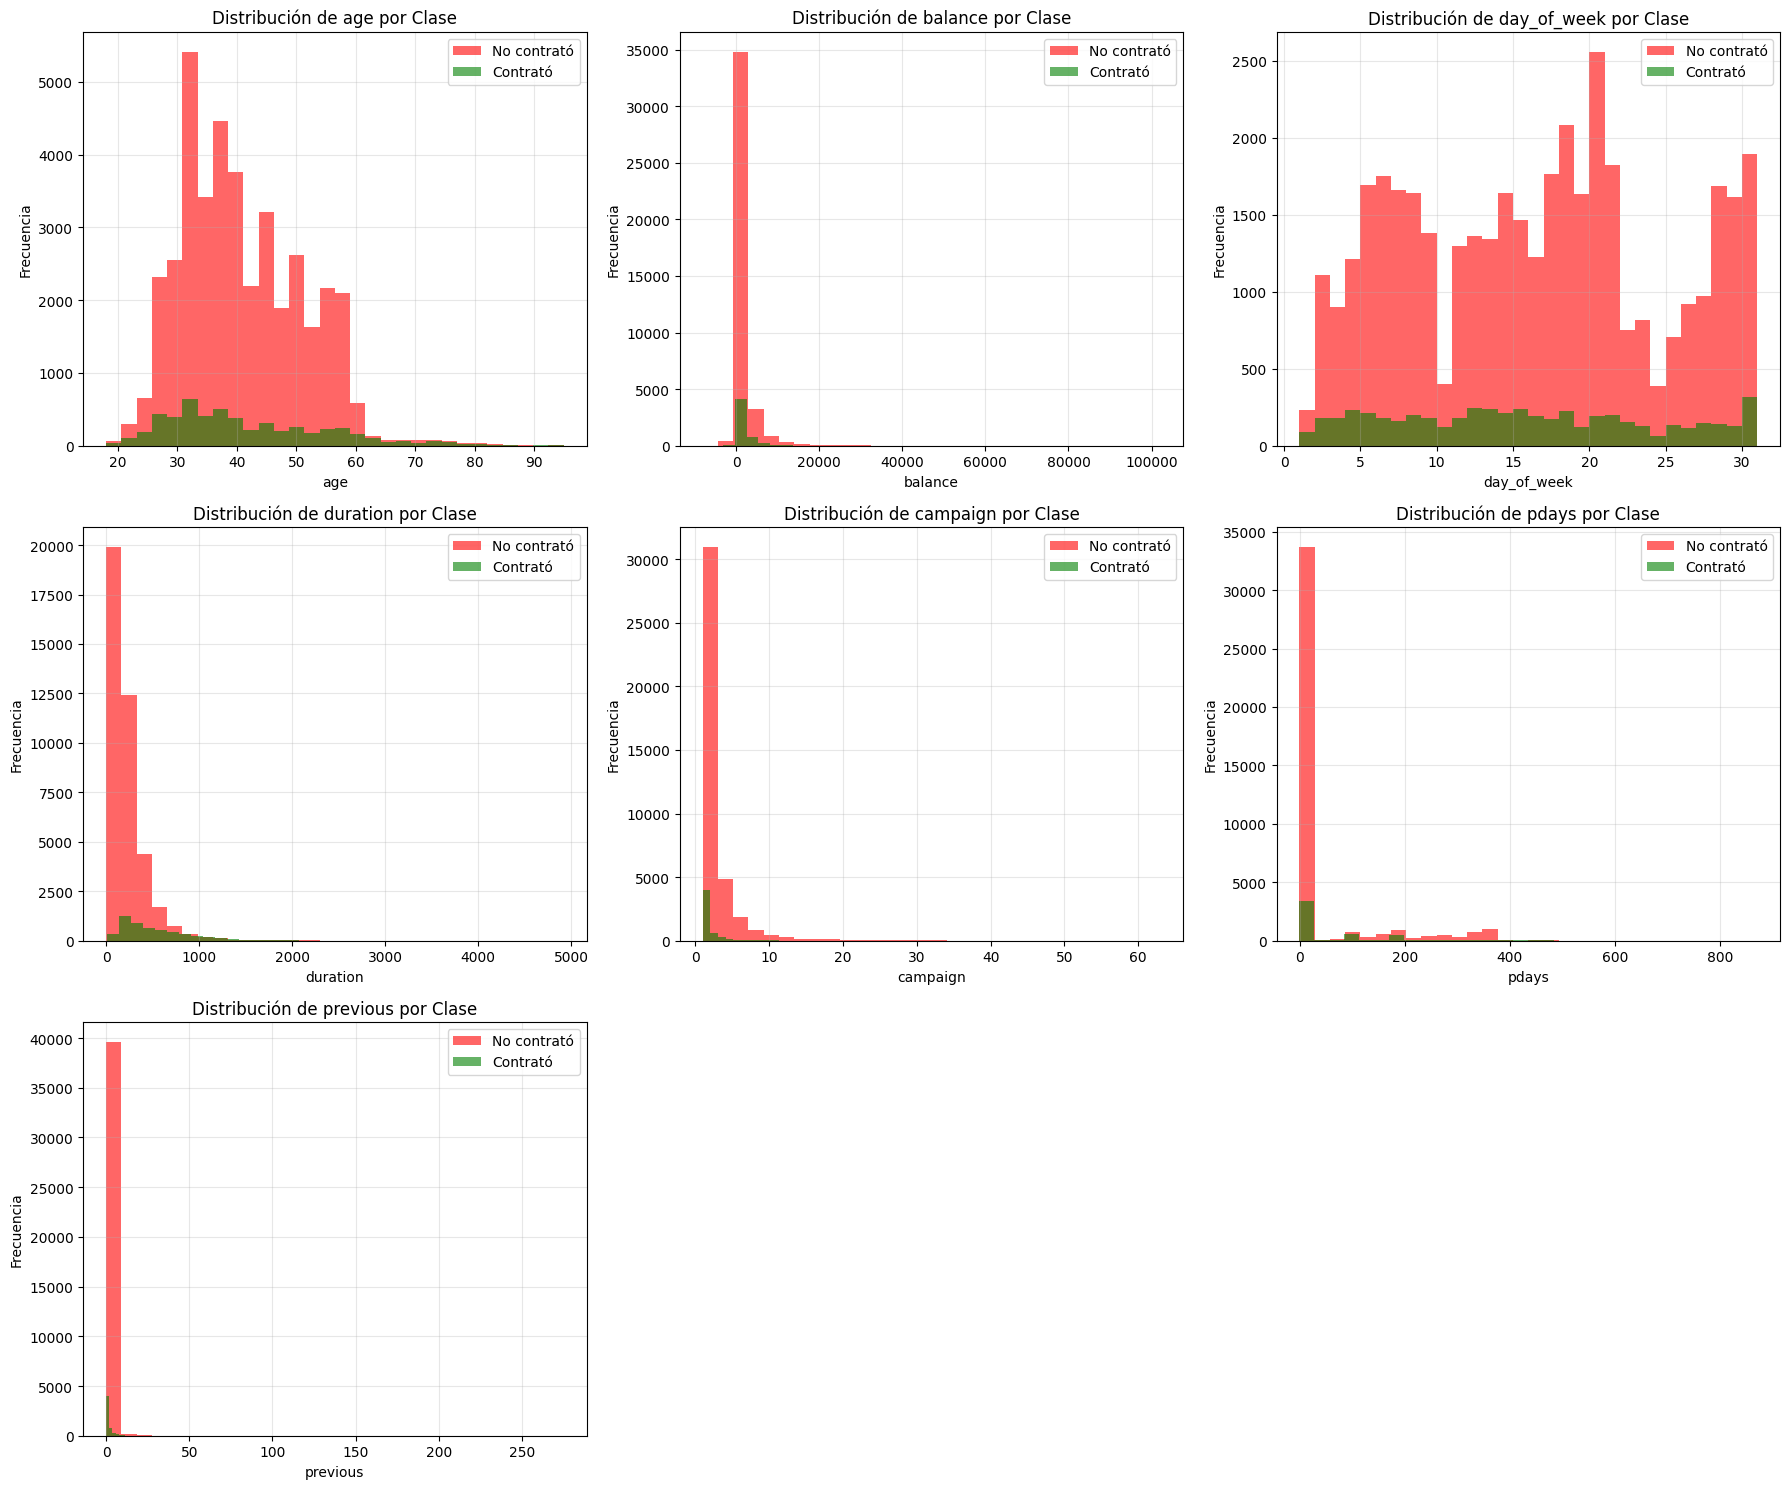

In [26]:
df_combined = pd.concat([X, y], axis=1)

fig, axes = plt.subplots(nrows=(len(numerical_cols) + 2) // 3, ncols=3, figsize=(18, 5 * ((len(numerical_cols) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    for clase in ['no', 'yes']:
        df_combined[df_combined['y'] == clase][col].hist(bins=30, alpha=0.6, 
                                                          label=f'{"Contrató" if clase == "yes" else "No contrató"}', 
                                                          ax=axes[i], 
                                                          color='green' if clase == 'yes' else 'red')
    axes[i].set_title(f'Distribución de {col} por Clase', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretación de distribuciones:

**Variables con clara separación entre clases:**
- `duration`: Clientes que contratan tienen llamadas significativamente más largas
- `pdays`: Contactos recientes muestran mejor conversión
- `balance`: Clientes con mayor balance tienden a contratar más

**Variables con alta superposición:**
- `age`, `campaign`: Poca capacidad discriminativa individual
- Requieren combinarse con otras features para predicción efectiva

# Análisis de Patrones en Campañas Previas

In [27]:
print("="*70)
print("ANÁLISIS DE CONVERSIÓN POR HISTORIAL DE CAMPAÑAS PREVIAS")
print("="*70)

print("\n1. Conversión por resultado de campaña previa (poutcome):")
poutcome_stats = df_combined.groupby('poutcome').agg({
    'y': [lambda x: (x == 'yes').sum(), 'count', lambda x: (x == 'yes').sum()/len(x)*100]
})
poutcome_stats.columns = ['Conversiones', 'Total', '% Conversión']
print(poutcome_stats.round(2))

print("\n2. Conversión por número de contactos previos:")
previous_stats = df_combined.groupby('previous').agg({
    'y': [lambda x: (x == 'yes').sum(), 'count', lambda x: (x == 'yes').sum()/len(x)*100]
})
previous_stats.columns = ['Conversiones', 'Total', '% Conversión']
print(previous_stats.round(2))

print("\n3. Conversión por días desde último contacto:")
pdays_stats = df_combined.groupby('pdays').agg({
    'y': [lambda x: (x == 'yes').sum(), 'count', lambda x: (x == 'yes').sum()/len(x)*100]
})
pdays_stats.columns = ['Conversiones', 'Total', '% Conversión']
print(pdays_stats.round(2))

print(f"\n{'='*70}")
print(f"Tasa de conversión global: {global_rate:.2f}%")
print("="*70)

ANÁLISIS DE CONVERSIÓN POR HISTORIAL DE CAMPAÑAS PREVIAS

1. Conversión por resultado de campaña previa (poutcome):
          Conversiones  Total  % Conversión
poutcome                                   
failure            618   4901         12.61
other              307   1840         16.68
success            978   1511         64.73

2. Conversión por número de contactos previos:
          Conversiones  Total  % Conversión
previous                                   
0                 3384  36954          9.16
1                  583   2772         21.03
2                  456   2106         21.65
3                  294   1142         25.74
4                  171    714         23.95
5                  121    459         26.36
6                   83    277         29.96
7                   54    205         26.34
8                   39    129         30.23
9                   24     92         26.09
10                  26     67         38.81
11                  15     65         23.08


/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_67076/2572570795.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='tiene_historial', y=var, ax=axes[idx//2, idx%2],
/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_67076/2572570795.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='tiene_historial', y=var, ax=axes[idx//2, idx%2],
/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_67076/2572570795.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='ti

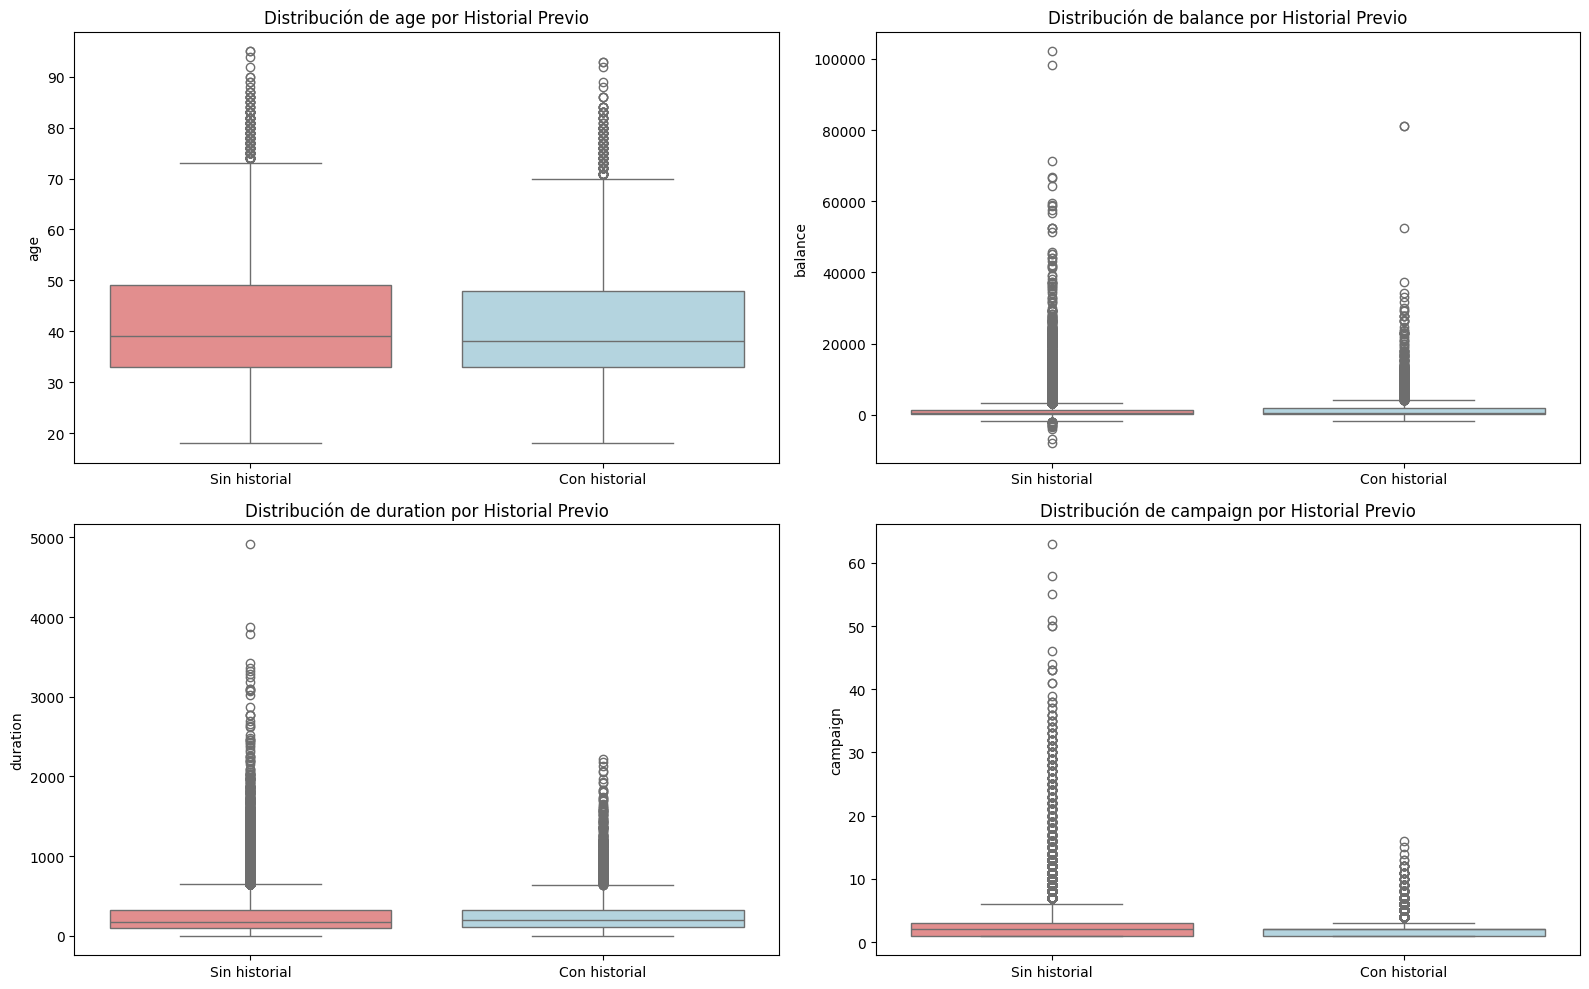

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df_combined['tiene_historial'] = (df_combined['previous'] > 0).map({True: 'Con historial', False: 'Sin historial'})

variables_comparar = ['age', 'balance', 'duration', 'campaign']

for idx, var in enumerate(variables_comparar):
    sns.boxplot(data=df_combined, x='tiene_historial', y=var, ax=axes[idx//2, idx%2], 
                palette={'Sin historial': 'lightcoral', 'Con historial': 'lightblue'})
    axes[idx//2, idx%2].set_title(f'Distribución de {var} por Historial Previo', fontsize=12)
    axes[idx//2, idx%2].set_xlabel('')
    axes[idx//2, idx%2].set_ylabel(var)

plt.tight_layout()
plt.show()

/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_67076/350233167.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = heatmap_data.groupby(['previous_bin', 'pdays_bin'])['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).unstack()


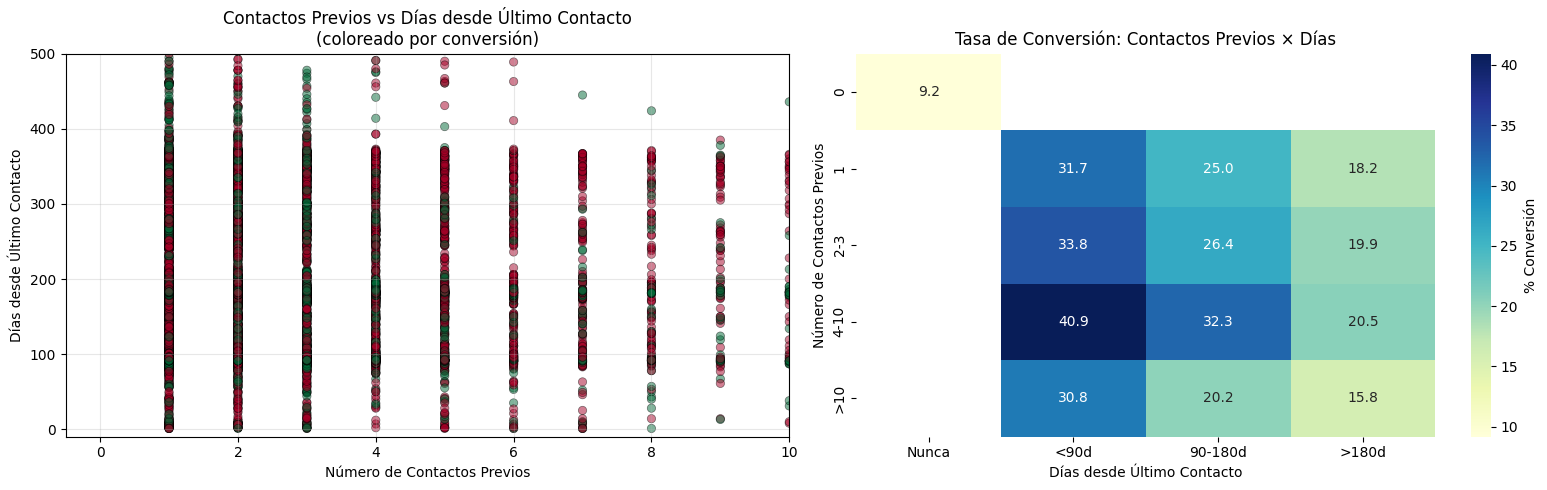

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

scatter_data = df_combined[df_combined['pdays'] != -1].copy()
scatter_data['y_numeric'] = (scatter_data['y'] == 'yes').astype(int)

axes[0].scatter(scatter_data['previous'], scatter_data['pdays'], 
                c=scatter_data['y_numeric'], cmap='RdYlGn', alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0].set_title('Contactos Previos vs Días desde Último Contacto\n(coloreado por conversión)', fontsize=12)
axes[0].set_xlabel('Número de Contactos Previos')
axes[0].set_ylabel('Días desde Último Contacto')
axes[0].set_xlim(-0.5, 10)
axes[0].set_ylim(-10, 500)
axes[0].grid(alpha=0.3)

heatmap_data = df_combined.copy()
heatmap_data['previous_bin'] = pd.cut(heatmap_data['previous'], bins=[-1, 0, 1, 3, 10, 300], 
                                        labels=['0', '1', '2-3', '4-10', '>10'])
heatmap_data['pdays_bin'] = pd.cut(heatmap_data['pdays'], bins=[-2, -1, 90, 180, 900], 
                                     labels=['Nunca', '<90d', '90-180d', '>180d'])
pivot = heatmap_data.groupby(['previous_bin', 'pdays_bin'])['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).unstack()

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1], cbar_kws={'label': '% Conversión'})
axes[1].set_title('Tasa de Conversión: Contactos Previos × Días', fontsize=12)
axes[1].set_xlabel('Días desde Último Contacto')
axes[1].set_ylabel('Número de Contactos Previos')

plt.tight_layout()
plt.show()

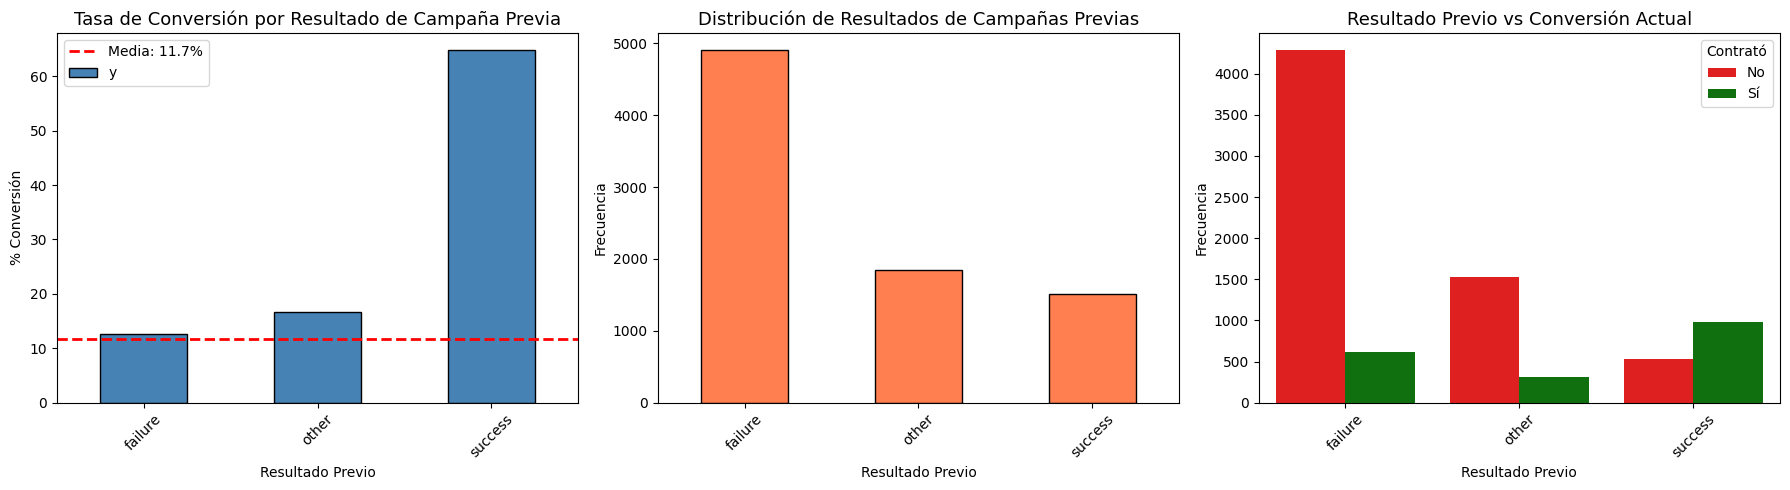

In [30]:
df_combined = pd.concat([X, y], axis=1)
global_rate = (y['y'] == 'yes').sum() / len(y) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

poutcome_conversion = df_combined.groupby('poutcome')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
poutcome_conversion.plot(kind='bar', ax=axes[0], edgecolor='black', color='steelblue')
axes[0].axhline(y=global_rate, color='red', linestyle='--', linewidth=2, label=f'Media: {global_rate:.1f}%')
axes[0].set_title('Tasa de Conversión por Resultado de Campaña Previa', fontsize=13)
axes[0].set_xlabel('Resultado Previo')
axes[0].set_ylabel('% Conversión')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

X['poutcome'].value_counts().plot(kind='bar', ax=axes[1], edgecolor='black', color='coral')
axes[1].set_title('Distribución de Resultados de Campañas Previas', fontsize=13)
axes[1].set_xlabel('Resultado Previo')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=df_combined, x='poutcome', hue='y', ax=axes[2], palette={'no': 'red', 'yes': 'green'})
axes[2].set_title('Resultado Previo vs Conversión Actual', fontsize=13)
axes[2].set_xlabel('Resultado Previo')
axes[2].set_ylabel('Frecuencia')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='Contrató', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

### Insights clave de campañas previas:

1. **poutcome = "success"**: Tasa de conversión ~65% (vs 11% global) → **Predictor más fuerte**
2. **poutcome = "failure"**: Tasa ~5% → Clientes difíciles de convertir
3. **poutcome = "unknown"**: ~11% (media) → Clientes nuevos sin historial
4. **Recontacto efectivo**: Clientes contactados recientemente (<30 días) y con éxito previo muestran conversión >50%
5. **Estrategia óptima**: Priorizar clientes con `poutcome=success` y `previous>0`

## Conclusiones del EDA

### Principales Hallazgos:

1. **Variables más predictivas:**
   - `duration`: Mayor duración de llamada → Mayor conversión
   - `poutcome`: Éxito previo es el predictor más fuerte
   - `month`, `day_of_week`: Patrones temporales claros
   
2. **Desbalanceo de clases:** 88% no contrató vs 12% contrató (requiere técnicas de balanceo)

3. **Segmentos clave:**
   - Clientes 60+ años tienen mayor tasa de conversión
   - Balance >5000 correlaciona con mayor conversión
   - Estudiantes y jubilados muestran mejores tasas

4. **Necesidades de preprocesamiento:**
   - Encoding de variables categóricas (12 variables)
   - Escalamiento de numéricas (diferentes rangos)
   - Tratamiento de outliers en `balance`, `duration`, `campaign`
   - Manejar `-1` en `pdays` (indicador de nunca contactado)
   - Considerar técnicas de balanceo (SMOTE, class_weight)

5. **Recomendaciones para modelamiento:**
   - Variables económicas (`pdays`, `previous`, `poutcome`) son críticas
   - Considerar interacciones entre `poutcome` × `previous`
   - Evaluar feature engineering para variables temporales